In [1]:
import torch
import torchvision

from torch import nn
#from helper_functions import set_seeds
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import os
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F

In [2]:
class COPDMultiModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        super(COPDMultiModel, self).__init__()
        self.copd_classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(), # 确保预测值非负
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),             
            nn.Linear(64, output_dim),
        )

    def forward(self, x):
        return self.copd_classifier(x)

    def safe_text(self, text, batch_size):
        if isinstance(text, list):
            return [str(t) if (t is not None and isinstance(t, str) and t.strip() != "") else "[UNK]" for t in text]
        elif isinstance(text, str):
            return [text if text.strip() != "" else "[UNK]"]
        else:
            return ["[UNK]"] * batch_size


In [4]:
舌色_labels = ['淡红舌', '淡白舌', '枯白舌', '红舌', '舌尖红', '舌边尖红', '暗红舌', '紫红舌', '绛舌', '淡紫舌', '紫暗舌', '绛紫舌', '瘀点舌', '瘀斑舌', '青紫']
舌形_labels = ['正常', '胖舌', '瘦舌', '老舌', '嫩舌', '肿胀舌', '齿痕舌', '点刺舌', '裂纹舌']
舌态_labels = ['正常', '歪斜', '强硬', '短缩', '萎软', '颤动']
苔质_labels = ['薄苔', '厚苔', '腻苔', '腐苔', '偏苔', '剥落苔', '地图舌', '镜面舌', '花剥苔', '类剥苔', '润苔', '滑苔', '燥苔', '糙苔']
苔色_labels = ['白苔', '黄白相兼苔', '黄苔', '浅黄苔', '深黄苔', '焦黄苔', '灰黑苔']
舌下脉络_labels = ['正常', '短而细，色淡', '粗胀，色青紫', '脉络曲张，青紫色较淡', '脉络曲张超过舌下脉的1/2，青紫色重']

面色_labels = ['面红黄隐隐明润含蓄', '面色淡白', '面色苍白', '面色晄白', '面色淡黄', '面色萎黄', '面色黄而鲜明', '面色黄而晦暗', '面色淡青', '面色青灰', 
             '面色青黄', '面色青紫', '面色通红', '面色暗红', '面色黑而黯淡', '面色黑而干焦', '面色黧黑', '面色略晦暗', '面色晦暗']
唇色_labels = ['红润', '淡白', '暗红', '赤肿', '青黑', '青紫', '口唇颜色暗', '口唇颜色暗,并且散在（瘀点）瘀斑']
局部特征_labels = ['无', '两颧潮红', '眼眶周围暗黑']
面部光泽_labels = ['少量光泽', '有光泽', '无光泽']

体质_labels = ['平和质', '阳虚质', '痰湿质', '湿热质', '气虚质', '阴虚质', '血瘀质', '特禀质', '气郁质', '基本是平和质', '血瘀质体质倾向',
             '阳虚质体质倾向', '湿热质体质倾向', '气虚质体质倾向',  '痰湿质体质倾向', '气郁质体质倾向', '阴虚质体质倾向']
'''
肺功能_labels = ['肺通气功能正常', '轻度阻塞性通气功能障碍', '肺通气功能大致正常', '中重度混合性通气功能障碍', '中度限制性通气功能障碍', '轻度限制性通气功能障碍',
              '中度混合性通气功能障碍', '重度混合性通气功能障碍', '中重度限制性通气功能障碍', '小气道通气功能障碍', '中度阻塞性通气功能障碍', '非特异性通气功能障碍',
              '轻度混合性通气功能障碍', '极重度混合性通气功能障碍', '重度限制性通气功能障碍']
'''

肺功能_labels = ['肺通气功能正常', '轻度通气功能障碍', '中度通气功能障碍', '重度通气功能障碍', ]

le_舌色 = LabelEncoder()
le_舌色.fit(舌色_labels)
舌色_mapping = dict(zip(舌色_labels, range(len(舌色_labels))))

le_舌形 = LabelEncoder()
le_舌形.fit(舌形_labels)
舌形_mapping = dict(zip(舌形_labels, range(len(舌形_labels))))

le_舌态 = LabelEncoder()
le_舌态.fit(舌态_labels)
舌态_mapping = dict(zip(舌态_labels, range(len(舌态_labels))))

le_苔质 = LabelEncoder()
le_苔质.fit(苔质_labels)
苔质_mapping = dict(zip(苔质_labels, range(len(苔质_labels))))

le_苔色 = LabelEncoder()
le_苔色.fit(苔色_labels)
苔色_mapping = dict(zip(苔色_labels, range(len(苔色_labels))))

le_舌下脉络 = LabelEncoder()
le_舌下脉络.fit(舌下脉络_labels)
舌下脉络_mapping = dict(zip(舌下脉络_labels, range(len(舌下脉络_labels))))

le_面色 = LabelEncoder()
le_面色.fit(面色_labels)
面色_mapping = dict(zip(面色_labels, range(len(面色_labels))))

le_唇色 = LabelEncoder()
le_唇色.fit(唇色_labels)
唇色_mapping = dict(zip(唇色_labels, range(len(唇色_labels))))

le_局部特征 = LabelEncoder()
le_局部特征.fit(局部特征_labels)
局部特征_mapping = dict(zip(局部特征_labels, range(len(局部特征_labels))))

le_面部光泽 = LabelEncoder()
le_面部光泽.fit(面部光泽_labels)
面部光泽_mapping = dict(zip(面部光泽_labels, range(len(面部光泽_labels))))

le_体质 = LabelEncoder()
le_体质.fit(体质_labels)
体质_mapping = dict(zip(体质_labels, range(len(体质_labels))))

le_肺功能 = LabelEncoder()
le_肺功能.fit(肺功能_labels)
肺功能_mapping = dict(zip(肺功能_labels, range(len(肺功能_labels))))

print("肺功能_mapping ", 肺功能_mapping)

# 定义一个函数，将多个标签的编码按位“或”合并
def encode_labels(value, mapping, isNoSplit = False):
    if isNoSplit :
        encoded = [mapping[value]]
    else :
        value_str = str(value).replace("，", ",")
        labels = [v.strip() for v in value_str.split(",")]    
        #print(labels)
        encoded = [mapping[label] for label in labels]
    # 按位“或”运算，将多个标签合并为一个数字
    return sum(2 ** i for i in encoded)

def decode_labels(encoded_value, mapping):
    # 获取所有标签的二进制表示
    decoded_labels = []
    for label, code in mapping.items():
        if encoded_value & (2 ** code):  # 检查当前标签是否存在（通过按位与运算）
            decoded_labels.append(label)
    return decoded_labels

class MultimodalDataset(Dataset):
    def __init__(self, data_file, image_dir, transform=None):
        self.df = pd.read_excel(data_file) 
        self.image_dir = image_dir
        self.transform = transform

        # 对每一行的舌形、舌色、面色进行编码
        self.df['舌形'] = self.df['舌形'].apply(lambda x: encode_labels(x, 舌形_mapping))
        self.df['舌色'] = self.df['舌色'].apply(lambda x: encode_labels(x, 舌色_mapping))
        self.df['舌态'] = self.df['舌态'].apply(lambda x: encode_labels(x, 舌态_mapping))
        self.df['苔质'] = self.df['苔质'].apply(lambda x: encode_labels(x, 苔质_mapping))
        self.df['苔色'] = self.df['苔色'].apply(lambda x: encode_labels(x, 苔色_mapping))

        self.df['面色'] = self.df['面色'].apply(lambda x: encode_labels(x, 面色_mapping))
        self.df['唇色'] = self.df['唇色'].apply(lambda x: encode_labels(x, 唇色_mapping, True))
        self.df['局部特征'] = self.df['局部特征'].apply(lambda x: encode_labels(x, 局部特征_mapping))
        self.df['面部光泽'] = self.df['面部光泽'].apply(lambda x: encode_labels(x, 面部光泽_mapping))

        self.df['主体质'] = self.df['主体质'].apply(lambda x: encode_labels(x, 体质_mapping))
        self.df['最终诊断意见'] = self.df['最终诊断意见'].apply(lambda x: 肺功能_mapping[x])

        # 提前把所有 图片加载到内存
        print("Preloading images into memory...")


    def __len__(self):
        return len(self.df)

    def safe_str(self, value):
        return value if pd.notna(value) else " "

    def __getitem__(self, idx):
        try:
            row = self.df.iloc[idx]
    
            #生理数据
            spo2 = row['血氧']
            rr = row['呼吸率']
   
            physiological_data = [
                #self.to_numeric(row['血氧']),
                #self.to_numeric(row['呼吸率']),
                #self.to_numeric(row['高压']),
                #self.to_numeric(row['低压']),
                #self.to_numeric(row['心率']),
                self.to_numeric(row['性别']),
                self.to_numeric(row['age']),
                self.to_numeric(row['bmi']),
            ]
            #print("physiological_data ", physiological_data)
    
            #生活习惯
            smokingHistory = self.safe_str(row['吸烟指数'])
            FHRD = row['呼吸疾病家族史']
            biofuelsHistory = row['生物燃料接触史']
            shortnessOfBreath = row['是否气促']
            cough = row['咳嗽']

            copdSQ =  row['COPD-SQ得分']
            constitution = row['主体质']

            #舌面
            faceColor = row['面色']
            lipColor = row['唇色']
            localFeat = row['局部特征']
            faceGloss = row['面部光泽']

            tongueColor = row['舌色']
            tongueShape = row['舌形']
            tongueCondition = row['舌态']
            coatingTexture = row['苔质']
            coatingColor = row['苔色']

            isCopd = row['最终诊断意见']
           
            result = {
                'physiological': torch.tensor(physiological_data, dtype=torch.float32),
                'smokingHistory' : torch.tensor(smokingHistory, dtype=torch.long).unsqueeze(0), 
                'FHRD' : torch.tensor(FHRD, dtype=torch.long).unsqueeze(0), 
                'biofuelsHistory' : torch.tensor(biofuelsHistory, dtype=torch.long).unsqueeze(0),
                'shortnessOfBreath' : torch.tensor(shortnessOfBreath, dtype=torch.long).unsqueeze(0),
                'cough' : torch.tensor(cough, dtype=torch.long).unsqueeze(0),
                #'copdSQ' : torch.tensor(copdSQ, dtype=torch.long).unsqueeze(0),
                'constitution' : torch.tensor(constitution, dtype=torch.long).unsqueeze(0),
                'faceColor' : torch.tensor(faceColor, dtype=torch.long).unsqueeze(0),
                'lipColor' : torch.tensor(lipColor, dtype=torch.long).unsqueeze(0),
                'localFeat' : torch.tensor(localFeat, dtype=torch.long).unsqueeze(0),
                'faceGloss' : torch.tensor(faceGloss, dtype=torch.long).unsqueeze(0),
                'tongueColor' : torch.tensor(tongueColor, dtype=torch.long).unsqueeze(0),
                'tongueShape' : torch.tensor(tongueShape, dtype=torch.long).unsqueeze(0),
                'tongueCondition' : torch.tensor(tongueCondition, dtype=torch.long).unsqueeze(0),
                'coatingTexture' : torch.tensor(coatingTexture, dtype=torch.long).unsqueeze(0),
                'coatingColor' : torch.tensor(coatingColor, dtype=torch.long).unsqueeze(0),
                'isCopd' : torch.tensor(isCopd, dtype=torch.long),
            }
    
            return result
        except Exception as e:
            print(f"\n❌ 错误发生在 idx={idx}")
            print(self.df.iloc[idx])  # 打印该行内容
            raise e


    def to_numeric(self, value):
        if pd.isna(value):  # 处理NaN/None
            return 0.0
        if isinstance(value, str):
            # 移除字符串中的非数字字符（如单位、空格）
            value = value.strip().replace('%', '').replace('mmHg', '').replace('次/分', '').replace('/', '').replace('kg', '')
            try:
                return float(value)  # 尝试转为浮点数
            except ValueError:
                return 0.0  # 转换失败返回0
        return float(value)  # 本身是数值型则直接转换

肺功能_mapping  {'肺通气功能正常': 0, '轻度通气功能障碍': 1, '中度通气功能障碍': 2, '重度通气功能障碍': 3}


In [5]:
# 数据加载
# 内部训练/交叉验证数据集：copd_tcm_out.xlsx
INTERNAL_DATA_PATH = r"D:\code\data\copd_patient\copd_tcm_out_label.xlsx"
# 外部独立验证数据集：copd_tcm_out_external.xlsx
EXTERNAL_DATA_PATH = r"D:\code\data\copd_patient\copd_tcm_out_external_review.xlsx"
IMAGE_ROOT = r"D:\workdir\中医\中医诊断\数据集\COPD\汇总数据\image"

dataset = MultimodalDataset(INTERNAL_DATA_PATH, IMAGE_ROOT)
external_dataset = MultimodalDataset(EXTERNAL_DATA_PATH, IMAGE_ROOT)

print("Internal dataset size:", len(dataset))
print("External dataset size:", len(external_dataset))

# 以下 train/test split 仅保留给旧代码调试；正式 DNN/RF 以 train_eval_kfold / evaluate_rf_with_shap 中的5折为准
dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)  # 80% 作为训练集
test_size = dataset_size - train_size  # 20% 作为测试集
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
testloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

model = COPDMultiModel(18, 128, len(肺功能_labels))


Preloading images into memory...
Preloading images into memory...
Internal dataset size: 231
External dataset size: 31


===== Table 1. Baseline characteristics of participants =====
age | 59.7 ± 16.0

BMI
<18.5|12(5.2%)
18.5 ≤ BMI < 24|126(54.5%)
24 ≤ BMI < 28|74(32.0%)
28 ≤ BMI < 100|19(8.2%)

gender
Female|115(49.8%)
Male|116(50.2%)

smoking
从不抽烟|139(60.2%)
1~<15包*年|25(10.8%)
15~<30包*年|24(10.4%)
≥30包*年|43(18.6%)

FHRD
无|196(84.8%)
有|35(15.2%)

biofuelsHistory
无接触|219(94.8%)
有接触|12(5.2%)

shortnessOfBreath
没有气促|120(51.9%)
在平地急行或爬小坡时感觉气促|60(26.0%)
平地正常行走时感觉气促|51(22.1%)

isCopd
肺通气功能正常|153(66.2%)
轻度通气功能障碍|4(1.7%)
中度通气功能障碍|27(11.7%)
重度通气功能障碍|47(20.3%)

constitution
痰湿质|69(29.9%)
基本是平和质|36(15.6%)
阳虚质|29(12.6%)
阴虚质|24(10.4%)
气虚质|19(8.2%)
平和质|18(7.8%)
血瘀质|14(6.1%)
气郁质|10(4.3%)
湿热质|10(4.3%)
痰湿质体质倾向|1(0.4%)
特禀质|1(0.4%)

faceColor
面红黄隐隐明润含蓄|83(35.9%)
面色黄而晦暗|42(18.2%)
面色萎黄|39(16.9%)
面色淡黄|25(10.8%)
面色淡白|9(3.9%)
面色晄白|8(3.5%)
面色黑而黯淡|6(2.6%)
面色青紫|6(2.6%)
面色黧黑|3(1.3%)
面色通红|3(1.3%)
面色暗红|2(0.9%)
面色苍白|2(0.9%)
面色淡青|1(0.4%)
面色晦暗|1(0.4%)
面色略晦暗|1(0.4%)

lipColor
红润|79(34.2%)
口唇颜色暗|51(22.1%)
淡白|46(19.9%)
暗红|39(16.9%)
青紫|10(4

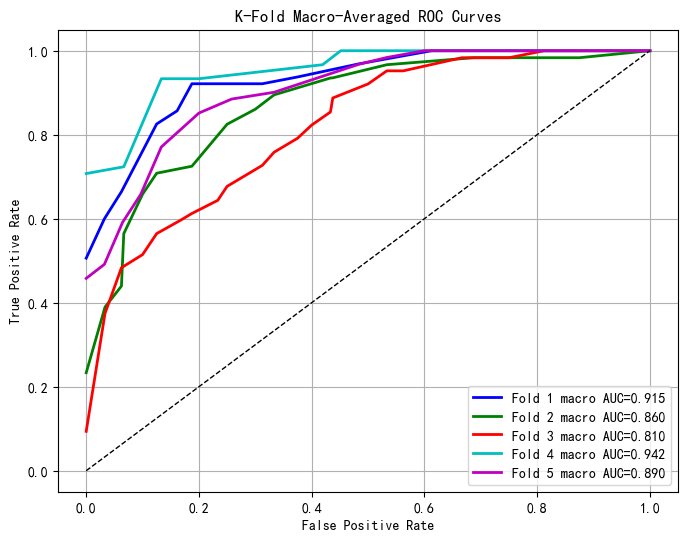

avg_shap_all_folds  (18,)

===== Overall Feature Importance (Mean SHAP) =====
              Feature   MeanSHAP
16     coatingTexture  15.189411
13        tongueColor   6.883527
8        constitution   6.031341
10           lipColor   5.287973
9           faceColor   4.602232
14        tongueShape   1.927395
1                 age   1.640906
2                 BMI   0.976042
11          localFeat   0.917244
17       coatingColor   0.541984
6   shortnessOfBreath   0.312472
0              gender   0.268340
3             smoking   0.123909
12          faceGloss   0.118890
7               cough   0.099702
4                FHRD   0.044623
5     biofuelsHistory   0.021967
15    tongueCondition   0.020207


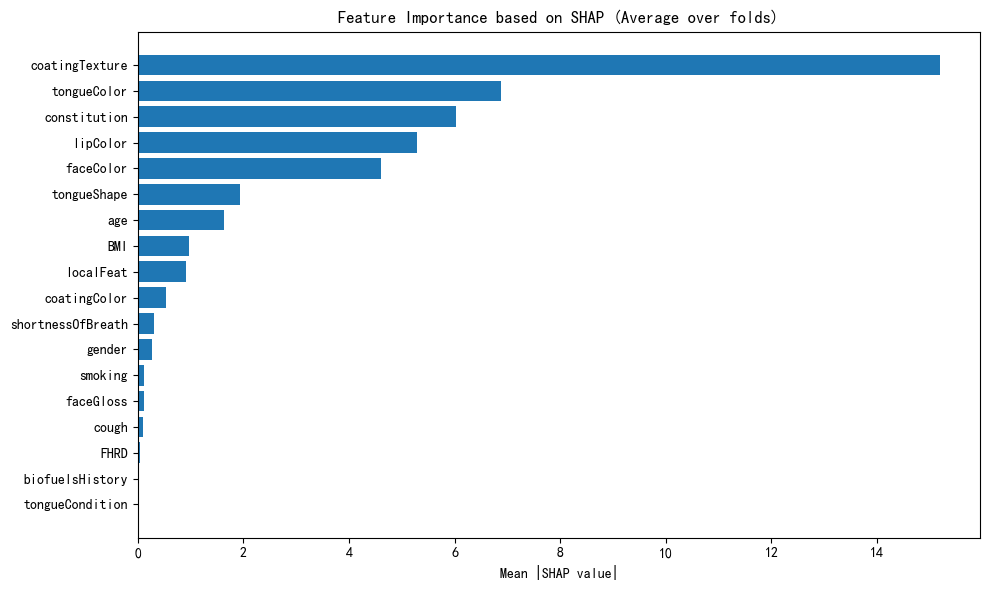


===== Overall Feature Importance (Class 0) =====
              Feature   MeanSHAP
16     coatingTexture  16.835276
10           lipColor   5.169460
13        tongueColor   4.599553
9           faceColor   4.536292
8        constitution   4.065662
14        tongueShape   1.888637
1                 age   1.777599
2                 BMI   1.055433
11          localFeat   0.960680
17       coatingColor   0.497737
6   shortnessOfBreath   0.302099
0              gender   0.284594
3             smoking   0.105862
12          faceGloss   0.104898
7               cough   0.100609
4                FHRD   0.053314
15    tongueCondition   0.032006
5     biofuelsHistory   0.026040


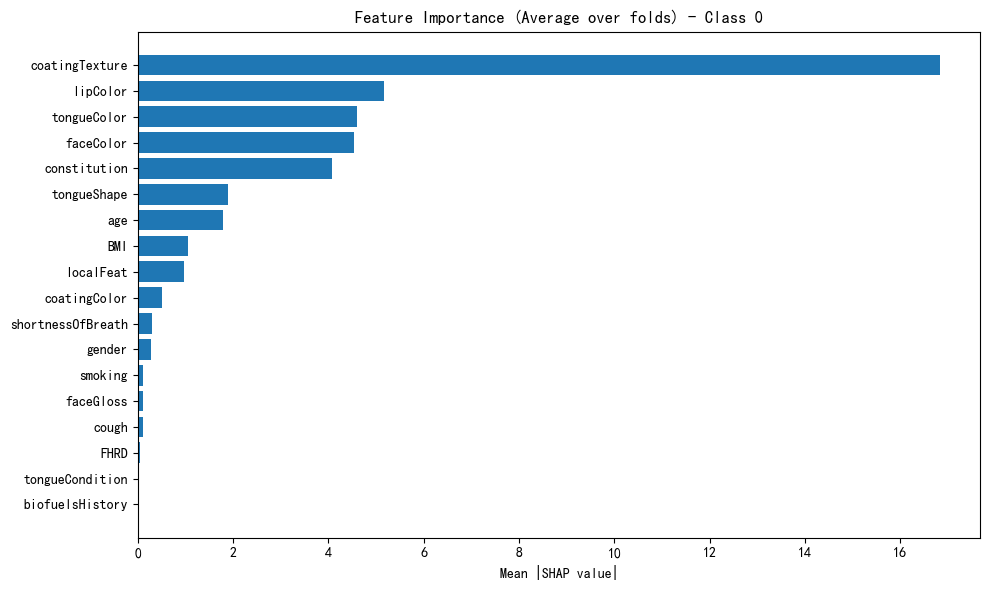


===== Overall Feature Importance (Class 1) =====
              Feature   MeanSHAP
16     coatingTexture  13.543547
13        tongueColor   9.167500
8        constitution   7.997020
10           lipColor   5.406485
9           faceColor   4.668172
14        tongueShape   1.966153
1                 age   1.504213
2                 BMI   0.896650
11          localFeat   0.873807
17       coatingColor   0.586231
6   shortnessOfBreath   0.322846
0              gender   0.252086
3             smoking   0.141956
12          faceGloss   0.132882
7               cough   0.098795
4                FHRD   0.035931
5     biofuelsHistory   0.017894
15    tongueCondition   0.008407


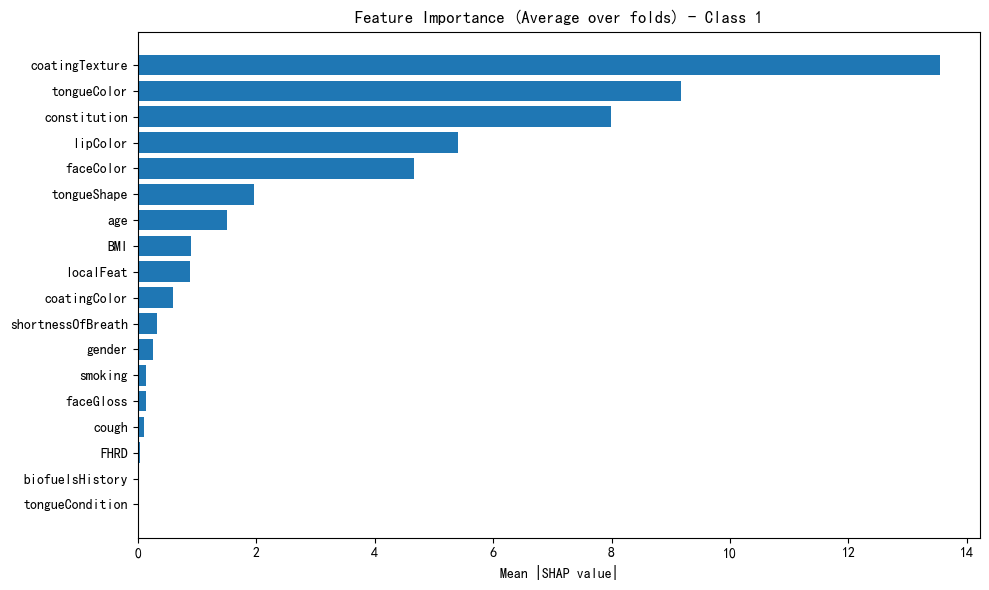

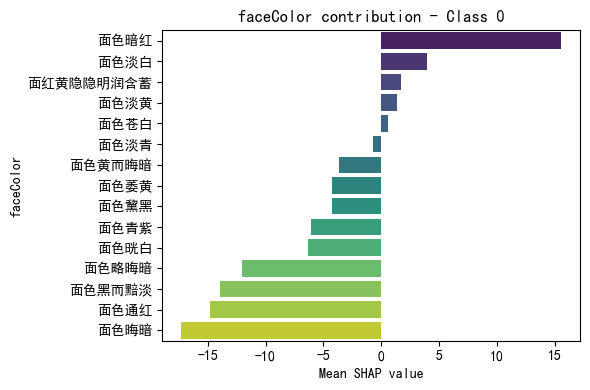

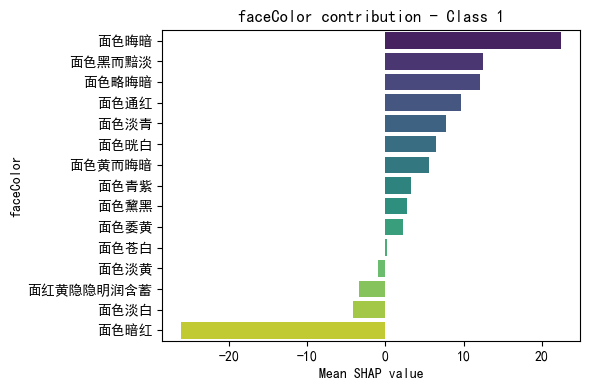

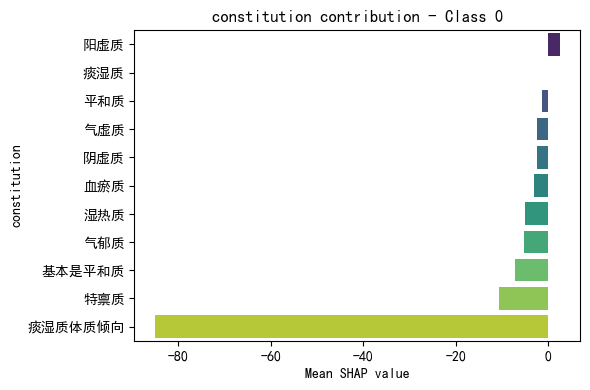

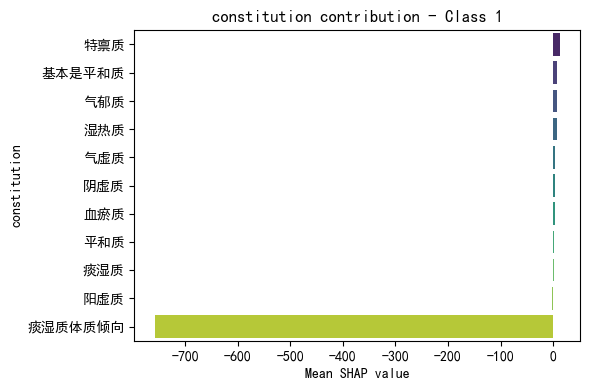

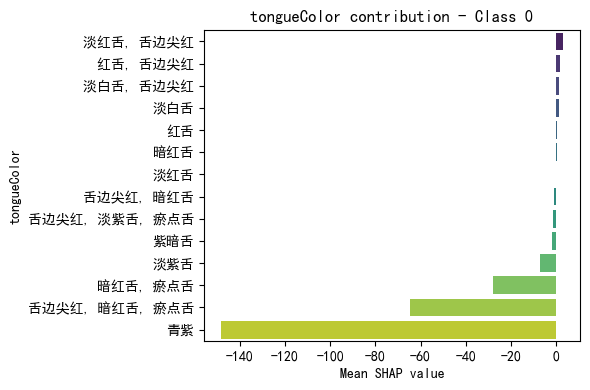

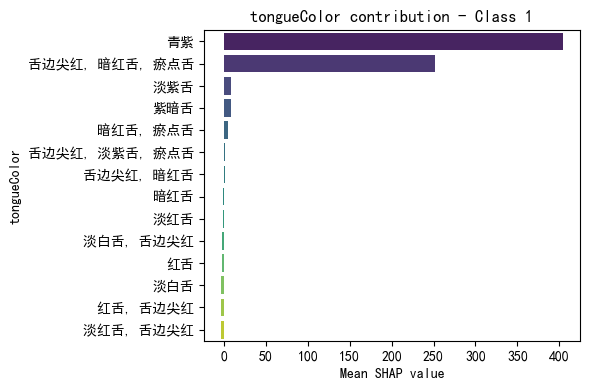

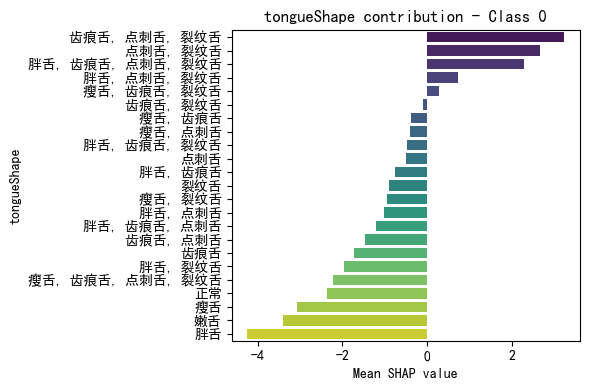

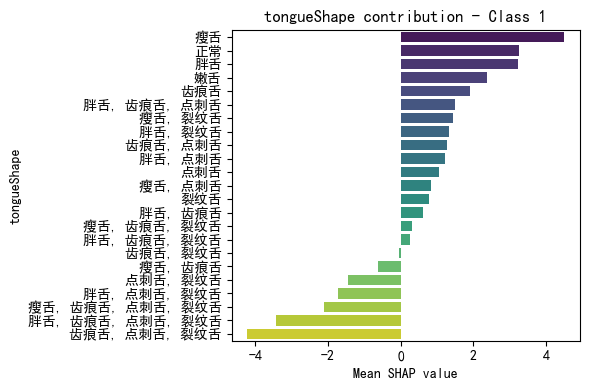

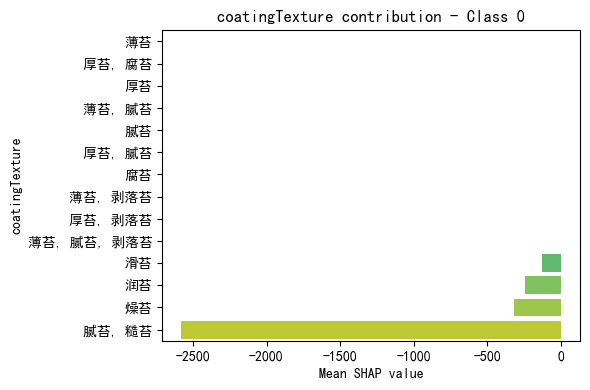

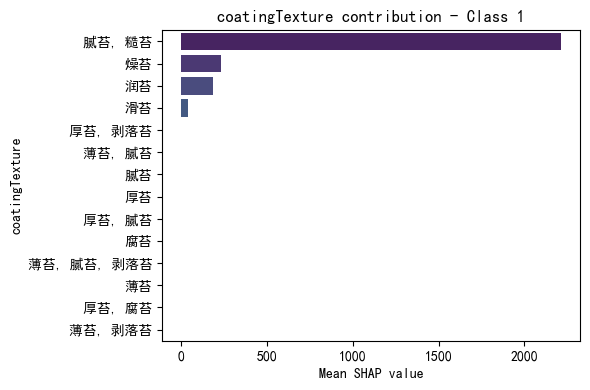

In [10]:
#深度神经网络
import shap
import matplotlib.pyplot as plt
import torch.optim as optim
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from itertools import cycle
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from scipy import stats

import random
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


categorical_features = ["faceColor", "constitution", "tongueColor", "tongueShape", "coatingTexture"]
feature_mappings = {
    "faceColor": 面色_mapping,
    "constitution": 体质_mapping,
    "tongueColor": 舌色_mapping,
    "tongueShape": 舌形_mapping,
    "coatingTexture": 苔质_mapping,  # 或者根据你数据命名
}
feature_names = [
    "gender", "age",  "BMI", "smoking", "FHRD", "biofuelsHistory", "shortnessOfBreath", 'cough', #"COPD-SQ Score",#
    "constitution", "faceColor", "lipColor", "localFeat", "faceGloss", "tongueColor", "tongueShape", 'tongueCondition', "coatingTexture", "coatingColor"
]

bins_dict = {'BMI':[0,18.5,24,28,100],
             'smoking':[1,2,3,4]
            } 

plt.rcParams['font.sans-serif'] = ['SimHei']   # 或者 ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False     # 解决负号显示问题

from scipy import stats
from scipy.stats import chi2_contingency, f_oneway, kruskal

categorical_mappings = {
    'constitution': 体质_mapping,
    'faceColor': 面色_mapping,
    'lipColor': 唇色_mapping,
    'localFeat': 局部特征_mapping,
    'faceGloss': 面部光泽_mapping,
    'tongueColor': 舌色_mapping,
    'tongueShape': 舌形_mapping,
    'tongueCondition': 舌态_mapping,
    'coatingTexture': 苔质_mapping,
    'coatingColor': 苔色_mapping,
}

def generate_baseline_table_multilabel_with_significance(dataset,
                                                         categorical_features_mapping,
                                                         group_label='isCopd'):
    """
    生成带组间显著性检验的基线表（Table 1）

    参数：
    - dataset: list，每个元素是包含特征字典的样本
    - categorical_features_mapping: dict，key=特征名, value=映射字典（用于decode）
    - group_label: 分组标签列名（默认 isCopd）
    """

    all_data = []
    for i in range(len(dataset)):
        item = dataset[i]
        row = {}

        # 连续特征
        row['age'] = item['physiological'][1].item()
        row['BMI'] = item['physiological'][2].item()
        #row['COPD-SQ Score'] = item['copdSQ'].item()
        row['FHRD'] = item['FHRD'].item()
        
        row['smoking'] = item['smokingHistory'].item()
        row['biofuelsHistory'] = item['biofuelsHistory'].item()
        row['shortnessOfBreath'] = item['shortnessOfBreath'].item()

        # 分类特征（bitwise编码）
        row['sex'] = item['physiological'][0].item()
        for feat in categorical_features_mapping.keys():
            row[feat] = item[feat].item()

        # 标签
        row[group_label] = item[group_label].item()
        all_data.append(row)

    df = pd.DataFrame(all_data)
    total = len(df)
    print("df.columns", df.columns)

    # --- 定义变量类型 ---
    continuous_features = ['age', 'BMI']#, 'COPD-SQ Score']
    categorical_basic = ['sex', 'smoking', 'FHRD', 'biofuelsHistory', 'shortnessOfBreath']

    summary = {}

    # --- 各组分开 ---
    groups = sorted(df[group_label].unique())
    group_names = [f"{group_label}={g}" for g in groups]

    for feat in df.columns:
        if feat == group_label:
            continue

        if feat in continuous_features:
            # 连续特征：报告均值±标准差
            descs = []
            values_by_group = []
            for g in groups:
                vals = df.loc[df[group_label]==g, feat].dropna()
                if len(vals) > 0:
                    descs.append(f"{vals.mean():.1f} ± {vals.std():.1f}")
                    values_by_group.append(vals)
                else:
                    descs.append("NA")

            # 多组 -> ANOVA，二组 -> t 检验
            if len(groups) > 2:
                stat, p = f_oneway(*values_by_group)
            else:
                p = stats.ttest_ind(values_by_group[0], values_by_group[1], equal_var=False)[1]

        elif feat in categorical_basic:
            # 生成列联表
            contingency = pd.crosstab(df[feat], df[group_label])
            # 卡方检验
            try:
                chi2, p, dof, ex = chi2_contingency(contingency)
            except:
                p = 1.0

            # 统计频率
            label_counts = {}
            for g in groups:
                sub = df[df[group_label] == g]
                total_g = len(sub)
                counts = sub[feat].value_counts()
                label_counts[g] = " | ".join([
                    f"{lbl} {cnt}({cnt/total_g*100:.1f}%)"
                    for lbl, cnt in counts.items()
                ])

        else:
            # 分类特征
            mapping = categorical_features_mapping.get(feat, None)
            if mapping is None:
                continue

            # 解码 bitwise
            decoded_lists = df[feat].apply(lambda x: decode_labels(int(x), mapping))
            df_decoded = df.copy()
            df_decoded[feat] = decoded_lists

            # 计算各标签频率
            label_counts = {}
            for g in groups:
                sub = df_decoded[df_decoded[group_label]==g]
                flat = [l for L in sub[feat] for l in L]
                total_g = len(sub)
                counts = pd.Series(flat).value_counts()
                label_counts[g] = " | ".join([
                    f"{lbl} {cnt}({cnt/total_g*100:.1f}%)"
                    for lbl, cnt in counts.items()
                ])

            # 构造列联表
            contingency = []
            labels_union = sorted({l for L in df_decoded[feat] for l in L})
            for lbl in labels_union:
                row_ct = []
                for g in groups:
                    sub = df_decoded[df_decoded[group_label]==g]
                    flat = [l for L in sub[feat] for l in L]
                    row_ct.append(flat.count(lbl))
                contingency.append(row_ct)

            # 卡方检验
            try:
                chi2, p, dof, ex = chi2_contingency(contingency)
            except:
                p = 1.0

        # ========= 显著性星号 =========
        if p < 0.001:
            p_str = f"{p:.3e} ***"
        elif p < 0.01:
            p_str = f"{p:.3f} **"
        elif p < 0.05:
            p_str = f"{p:.3f} *"
        else:
            p_str = f"{p:.3f}"

        # ========= 汇总 =========
        if feat in continuous_features:
            row_summary = descs + [p_str]
        else:
            row_summary = [label_counts.get(g, 'NA') for g in groups] + [p_str]

        summary[feat] = row_summary

    # 组装结果 DataFrame
    columns = group_names + ['p值']
    summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=columns)
    summary_df = summary_df.reset_index().rename(columns={'index': '特征'})

    return summary_df

def generate_baseline_with_significance(dataset, feature_mappings=None):
    """
    根据 df（包含 isCopd 标签）生成含显著性检验的 Table 1。
    feature_mappings: dict，可选，映射分类特征标签到中文名称。
    返回：pandas.DataFrame，可直接输出或保存为 CSV
    """
    df = get_all_data_df(dataset)

    results = []
    # COPD vs 非COPD 分组
    copd_group = df[df['isCopd'] > 0]
    noncopd_group = df[df['isCopd'] == 0]

    for feat in df.columns:
        if feat == 'isCopd':
            continue

        col_data = df[feat].dropna()

        # --- 连续变量（年龄、BMI、COPD-SQ） ---
        if np.issubdtype(col_data.dtype, np.number) and col_data.nunique() > 5:
            # 正态性检验（Shapiro-Wilk）
            stat1, p1 = stats.shapiro(copd_group[feat]) if len(copd_group[feat])>=3 else (0,1)
            stat2, p2 = stats.shapiro(noncopd_group[feat]) if len(noncopd_group[feat])>=3 else (0,1)
            normal = (p1>0.05 and p2>0.05)
            if normal:
                stat, pval = stats.ttest_ind(copd_group[feat], noncopd_group[feat], equal_var=False)
            else:
                stat, pval = stats.mannwhitneyu(copd_group[feat], noncopd_group[feat])
            mean1, std1 = copd_group[feat].mean(), copd_group[feat].std()
            mean2, std2 = noncopd_group[feat].mean(), noncopd_group[feat].std()
            results.append({
                "Feature": feat,
                "COPD组": f"{mean1:.1f} ± {std1:.1f}",
                "非COPD组": f"{mean2:.1f} ± {std2:.1f}",
                "p值": format_pval(pval)
            })

        # --- 分类变量（性别、舌色等） ---
        else:
            contingency = pd.crosstab(df[feat], df['isCopd'])
            if contingency.shape[0] > 1 and contingency.shape[1] > 1:
                chi2, pval, _, _ = stats.chi2_contingency(contingency)
            else:
                pval = np.nan
            # 转换为 label 文字
            if feature_mappings and feat in feature_mappings:
                mapping = feature_mappings[feat]
                labels = [mapping.get(int(k), k) for k in contingency.index]
            else:
                labels = contingency.index
            results.append({
                "Feature": feat,
                "COPD组": summarize_category(contingency.iloc[:,1] if contingency.shape[1]>1 else contingency.iloc[:,0], labels),
                "非COPD组": summarize_category(contingency.iloc[:,0], labels),
                "p值": format_pval(pval)
            })

    table1 = pd.DataFrame(results)
    return table1


def summarize_category(series, labels):
    """将分类统计结果转为 'A(%) | B(%)' 字符串"""
    total = series.sum()
    parts = [f"{lbl} {cnt}({cnt/total*100:.1f}%)" for lbl, cnt in zip(labels, series)]
    return " | ".join(parts)


def format_pval(p):
    """返回带显著性标记的p值"""
    if pd.isna(p):
        return "-"
    if p < 0.001:
        return "<0.001 ***"
    elif p < 0.01:
        return f"{p:.3f} **"
    elif p < 0.05:
        return f"{p:.3f} *"
    else:
        return f"{p:.3f}"

def get_all_data_df(dataset):
    all_data = []
    for i in range(len(dataset)):
        item = dataset[i]
        row = {
            'age': item['physiological'][1].item(),
            'BMI': item['physiological'][2].item(),
            #'COPD-SQ Score': item.get('copdSQ', torch.tensor(0)).item() if isinstance(item.get('copdSQ', None), torch.Tensor) else (item['copdSQ'].item() if 'copdSQ' in item else np.nan),
            'gender': item['physiological'][0].item(),
            'smoking': item['smokingHistory'].item(),
            'FHRD': item['FHRD'].item(),
            'biofuelsHistory': item['biofuelsHistory'].item(),
            'shortnessOfBreath': item['shortnessOfBreath'].item(),
            'constitution': item['constitution'].item(),
            'faceColor': item['faceColor'].item(),
            'lipColor': item['lipColor'].item(),
            'localFeat': item['localFeat'].item(),
            'faceGloss': item['faceGloss'].item(),
            'tongueColor': item['tongueColor'].item(),
            'tongueShape': item['tongueShape'].item(),
            'tongueCondition': item['tongueCondition'].item(),
            'coatingTexture': item['coatingTexture'].item(),
            'coatingColor': item['coatingColor'].item(),
            'isCopd': item['isCopd'].item(),
        }
        all_data.append(row)

    df = pd.DataFrame(all_data)
    return df

def generate_baseline_text(dataset, bins_dict=None, save_txt=None):
    """
    为 MultimodalDataset 生成可拷贝的分块文本输出。
    - bins_dict: dict, 如 {'BMI':[0,18.5,24,28,100], 'COPD-SQ Score':[0,16,100]}
    - save_txt: 若给出路径，则把结果写到该 txt 文件
    返回：字符串（可打印或保存）
    """
    df = get_all_data_df(dataset)
    total = len(df)

    # 哪些特征按区间显示（每个区间一行）
    if bins_dict is None:
        bins_dict = {'BMI':[0,18.5,24,28,100], 'COPD-SQ Score':[0,16,100]}

    # 指定哪些是“普通单值分类” vs “bitmask 多标签”（仅对多标签字段用 decode_labels）
    single_value_cats = {
        'gender': {1:'Male', 0:'Female'},
        'smoking': {1:'从不抽烟', 2:'1~<15包*年', 3:'15~<30包*年', 4:'≥30包*年'},
        'FHRD': {1:'无', 2:'有'},
        'biofuelsHistory': {1:'无接触', 2:'有接触'},
        'shortnessOfBreath': {1:'没有气促', 2:'在平地急行或爬小坡时感觉气促', 3:'平地正常行走时感觉气促'},
        'isCopd': {0:'肺通气功能正常', 1:'轻度通气功能障碍', 2:'中度通气功能障碍', 3:'重度通气功能障碍'}  # 如果肺功能_mapping 是 label->index，注意下面会用 mapping.get(int(idx))
    }

    # 多标签 bitmask 字段及其 mapping（mapping 是 label->index）
    multilabel_fields = {
        'constitution': 体质_mapping,
        'faceColor': 面色_mapping,
        'lipColor': 唇色_mapping,
        'localFeat': 局部特征_mapping,
        'faceGloss': 面部光泽_mapping,
        'tongueColor': 舌色_mapping,
        'tongueShape': 舌形_mapping,
        'tongueCondition': 舌态_mapping,
        'coatingTexture': 苔质_mapping,
        'coatingColor': 苔色_mapping,
    }

    # 开始构造文本
    lines = []
    # 连续特征：mean ± std 或按区间
    continuous_feats = ['age', 'BMI']#, 'COPD-SQ Score']
    for feat in continuous_feats:
        if feat in bins_dict:
            bins = bins_dict[feat]
            # 构造标签文本
            bin_labels = []
            for i in range(len(bins)-1):
                if i == 0:
                    lbl = f"<{bins[i+1]}"
                elif i == len(bins)-2:
                    lbl = f"{bins[i]} ≤ {feat} < {bins[i+1]}"
                else:
                    lbl = f"{bins[i]} ≤ {feat} < {bins[i+1]}"
                bin_labels.append(lbl)
            # pd.cut 并统计
            df['_bin'] = pd.cut(df[feat], bins=bins, labels=bin_labels, right=False)
            counts = df['_bin'].value_counts().reindex(bin_labels, fill_value=0)
            lines.append(f"{feat}")
            for lbl, cnt in counts.items():
                lines.append(f"{lbl}|{cnt}({cnt/total*100:.1f}%)")
            lines.append("")  # 空行分隔
        else:
            mean, std = df[feat].mean(), df[feat].std()
            #lines.append(f"{feat}")
            lines.append(f"{feat} | {mean:.1f} ± {std:.1f}")
            lines.append("")

    # 单值分类逐行打印
    for feat, mapping in single_value_cats.items():
        lines.append(f"{feat}")
        counts = df[feat].value_counts().sort_index()
        for idx, cnt in counts.items():
            # mapping 可能是 {int:label} 或 {label:int}，我们先尝试用 get(int(idx))
            name = mapping.get(int(idx), mapping.get(str(idx), str(idx)))
            lines.append(f"{name}|{cnt}({cnt/total*100:.1f}%)")
        lines.append("")

    # 多标签（bitmask）字段：逐标签统计并逐行打印（按出现次数降序）
    for feat, mapping in multilabel_fields.items():
        lines.append(f"{feat}")
        # 对每个样本 decode（注意 mapping 是 label->index）
        decoded_all = []
        for val in df[feat]:
            try:
                decoded = decode_labels(int(val), mapping)   # 你已有 decode_labels 实现
                decoded_all.extend(decoded)
            except Exception:
                # 忽略无法解码的（可能 NaN 或非法值）
                pass
        if len(decoded_all) == 0:
            lines.append(f"Unknown\t{total}({100.0:.1f}%)")
            lines.append("")
            continue
        # 统计
        s = pd.Series(decoded_all)
        counts = s.value_counts()
        for lbl, cnt in counts.items():
            lines.append(f"{lbl}|{cnt}({cnt/total*100:.1f}%)")
        lines.append("")

    out_text = "\n".join(lines)

    if save_txt:
        with open(save_txt, "w", encoding="utf-8") as f:
            f.write(out_text)

    return out_text




# ---- 特征值 SHAP 汇总函数 ----
def feature_value_shap_summary(shap_values, data, feature_names, feature_name, mapping):
    feat_idx = feature_names.index(feature_name)
    feat_vals = data[:, feat_idx]
    shap_feat = shap_values[:, feat_idx, :]  # shape: (n_samples, n_classes)

    summary = {}
    n_classes = shap_feat.shape[1]
    for class_idx in range(n_classes):
        df = pd.DataFrame({"encoded_value": feat_vals, "shap": shap_feat[:, class_idx]})
        # 解码特征值
        df["decoded_labels"] = df["encoded_value"].apply(lambda x: ", ".join(decode_labels(int(x), mapping)))
        grouped = df.groupby("decoded_labels")["shap"].mean().sort_values(ascending=False)
        summary[f"Class_{class_idx}"] = grouped
    return summary

# ---- 计算每折每分类的平均 SHAP ----
def compute_classwise_shap_avg(shap_values):
    """
    shap_values: np.array (n_samples, n_features, n_classes)
    返回: np.array (n_features, n_classes) 每个特征每个分类的平均 |SHAP|
    """
    return np.mean(np.abs(shap_values), axis=0)  # shape: (n_features, n_classes)



def extract_xy_from_dataset_for_biclass(dataset_obj):
    """从 MultimodalDataset 中提取 X/y，二分类标签：0=正常，1=通气功能异常/COPD。
    注意：不使用 sample.pop，避免改变 dataset 内部样本。"""
    X_list, y_list = [], []
    for idx in range(len(dataset_obj)):
        sample = dataset_obj[idx]
        label_raw = sample["isCopd"].item()
        bin_label = 0 if label_raw == 0 else 1
        feat_list = [v for k, v in sample.items() if k != "isCopd"]
        x = torch.cat(feat_list, dim=0).numpy()
        X_list.append(x)
        y_list.append(bin_label)
    return np.asarray(X_list), np.asarray(y_list)


def compute_binary_metrics_from_probs(y_true, prob_pos, threshold=0.5):
    """统一计算 ACC、F1、AUC、Sensitivity、Specificity。"""
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    prob_pos = np.asarray(prob_pos).astype(float).reshape(-1)
    y_pred = (prob_pos >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    auc = roc_auc_score(y_true, prob_pos) if len(np.unique(y_true)) == 2 else np.nan
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    sensitivity = TP / (TP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)
    return acc, f1, auc, sensitivity, specificity, cm

# ==== k-fold 训练 & 测试 ====
def train_eval_kfold(dataset, N=5, k=5, num_epochs=300, batch_size=32, lr=0.0005, seed=42, external_dataset=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ======= ① 输出 Table 1 =======
    baseline_table = generate_baseline_text(dataset)
    print("===== Table 1. Baseline characteristics of participants =====")
    print(baseline_table)   

    # 输出带显著性检验的 Table 1
    summary_df = generate_baseline_table_multilabel_with_significance(
        dataset=dataset,
        categorical_features_mapping=categorical_mappings,
        group_label='isCopd'  # 0,1,2,3 四类
    )
    pd.set_option('display.max_columns', None)      # 显示所有列
    pd.set_option('display.max_rows', None)         # 显示所有行
    pd.set_option('display.width', 2000)            # 调整打印宽度
    pd.set_option('display.max_colwidth', None)     # 每列完整显示（不省略“...”）
    #pd.set_option('display.expand_frame_repr', False)  # 打印为单个表格，不换行
    print(summary_df)
    summary_df.to_excel("baseline_table.xlsx", index=False)

    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)
    all_auc = []
    all_acc = []
    all_f1 = []
    all_sens = []
    all_spec = []

    # 外部验证集：每一折训练完成后，用该折模型直接验证外部集
    ext_all_acc, ext_all_f1, ext_all_auc, ext_all_sens, ext_all_spec = [], [], [], [], []
    # 保存每折外部验证的逐样本预测，用于后续bootstrap 95% CI
    ext_pred_rows = []

    all_shap_values = []
    all_data_list = []
    all_shap_explanations = []
    fold_shap_avg = []
    # 存储每折的 roc curve
    fold_fpr = []
    fold_tpr = []

    # 保存所有测试集
    X_tests, y_tests = [], []

    X, y = extract_xy_from_dataset_for_biclass(dataset)
    print("X.shape", X.shape)
    print(" y.shape",  y.shape)

    if external_dataset is not None:
        X_external, y_external = extract_xy_from_dataset_for_biclass(external_dataset)
        external_tensor_dataset = torch.utils.data.TensorDataset(
            torch.tensor(X_external, dtype=torch.float32),
            torch.tensor(y_external, dtype=torch.long)
        )
        external_loader = torch.utils.data.DataLoader(external_tensor_dataset, batch_size=batch_size, shuffle=False)
        print("External X.shape", X_external.shape)
        print("External y.shape", y_external.shape)
        print("External label counts:", pd.Series(y_external).value_counts().to_dict())
    else:
        external_loader = None

    sample = dataset[0]

    print("dataset[0].keys():", dataset[0].keys())
    print("dataset[0].keys():", dataset[0].values())
    for i, k in enumerate(sample.keys()):
        v = sample[k]
        shape = tuple(v.shape) if torch.is_tensor(v) else None
        print(i, k, shape, v.dtype if torch.is_tensor(v) else type(v))

     # ===== ① 全局检查 =====
    print("全体样本中是否存在 NaN:", np.isnan(X).any())
    print("全体样本中是否存在 Inf:", np.isinf(X).any())


    for fold, (train_idx, test_idx) in enumerate(kf.split(X, y)):
        print(f"\n===== Fold {fold+1}/{k} =====")
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        X_tests.append(X_test)
        y_tests.append(y_test)
       
        model = COPDMultiModel(input_dim=X.shape[1], hidden_dim=128, output_dim=2).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        # ---- DataLoader ----
        train_dataset = torch.utils.data.TensorDataset(
            torch.tensor(X_train, dtype=torch.float32),
            torch.tensor(y_train, dtype=torch.long)
        )
        test_dataset = torch.utils.data.TensorDataset(
            torch.tensor(X_test, dtype=torch.float32),
            torch.tensor(y_test, dtype=torch.long)
        )
        train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        # ---- Training ----
        for epoch in range(num_epochs):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                outputs = model(xb)
                loss = criterion(outputs, yb)
                loss.backward()
                optimizer.step()

        # ---- Evaluation ----
        model.eval()
        all_probs = []
        all_labels = []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(device)
                outputs = model(xb)
                probs = torch.softmax(outputs, dim=1).cpu().numpy()
                all_probs.append(probs)
                all_labels.append(yb.numpy())
        all_probs = np.vstack(all_probs)
        all_labels = np.concatenate(all_labels)

        # ---- Metrics ----
        y_pred = np.argmax(all_probs, axis=1)
        acc = accuracy_score(all_labels, y_pred)
        f1 = f1_score(all_labels, y_pred, average="macro")
        auc = roc_auc_score(
            all_labels, all_probs[:, 1]
        )

        cm = confusion_matrix(all_labels, y_pred, labels=[0, 1])
        TN, FP, FN, TP = cm.ravel()
        sensitivity_mean = TP / (TP + FN + 1e-8)
        specificity_mean = TN / (TN + FP + 1e-8)
        
        
        all_acc.append(acc)
        all_f1.append(f1)
        all_auc.append(auc)
        all_sens.append(sensitivity_mean)
        all_spec.append(specificity_mean)

        print(f"Fold {fold+1}: ACC={acc:.3f}, F1={f1:.3f}, AUC={auc:.3f}, "
              f"Sensitivity={sensitivity_mean:.3f}, Specificity={specificity_mean:.3f}")

        # ---- External validation: 用当前fold训练后的DNN模型直接验证外部集 ----
        if external_loader is not None:
            model.eval()
            ext_probs_list, ext_labels_list = [], []
            with torch.no_grad():
                for xb_ext, yb_ext in external_loader:
                    xb_ext = xb_ext.to(device)
                    logits_ext = model(xb_ext)
                    probs_ext = torch.softmax(logits_ext, dim=1).cpu().numpy()
                    ext_probs_list.append(probs_ext)
                    ext_labels_list.append(yb_ext.numpy())
            ext_probs = np.vstack(ext_probs_list)
            ext_labels = np.concatenate(ext_labels_list)
            ext_acc, ext_f1, ext_auc, ext_sen, ext_spe, ext_cm = compute_binary_metrics_from_probs(
                ext_labels, ext_probs[:, 1], threshold=0.5
            )
            ext_all_acc.append(ext_acc)
            ext_all_f1.append(ext_f1)
            ext_all_auc.append(ext_auc)
            ext_all_sens.append(ext_sen)
            ext_all_spec.append(ext_spe)
            ext_pred = (ext_probs[:, 1] >= 0.5).astype(int)
            for sample_i, (yy, ss, pp) in enumerate(zip(ext_labels, ext_probs[:, 1], ext_pred)):
                ext_pred_rows.append({
                    "fold": fold + 1,
                    "sample_index": sample_i,
                    "y_true": int(yy),
                    "y_score": float(ss),
                    "y_pred": int(pp),
                    "is_wrong": bool(int(yy) != int(pp)),
                    "error_type": "Correct" if int(yy) == int(pp) else ("FN_false_negative" if int(yy) == 1 and int(pp) == 0 else "FP_false_positive")
                })
            print(f"[External DNN] Fold {fold+1}: ACC={ext_acc:.3f}, F1={ext_f1:.3f}, AUC={ext_auc:.3f}, "
                  f"Sensitivity={ext_sen:.3f}, Specificity={ext_spe:.3f}")
            print("[External DNN] Confusion Matrix:")
            print(ext_cm)

        # ---- SHAP Values ----
        background = torch.tensor(X_train[:100], dtype=torch.float32).to(device)
        test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
        explainer = shap.GradientExplainer(model, background)
        shap_exp = explainer(test_tensor)
        all_shap_explanations.append(shap_exp)
        shap_values = shap_exp.values
        all_shap_values.append(shap_values)
        all_data_list.append(shap_exp.data)
        print("shap_exp.values =", shap_exp.values.shape)
        #print(np.allclose(shap_exp.values, explainer.shap_values(test_tensor))) 

        # ---- 每折每分类特征平均 SHAP (绝对值) ----
        classwise_shap_avg = compute_classwise_shap_avg(shap_values)  # shape: (n_features, n_classes)
        fold_shap_avg.append(classwise_shap_avg)
        print("classwise_shap_avg =", classwise_shap_avg.shape)

        # ---- 每折每分类打印 ----
        for class_idx in range(classwise_shap_avg.shape[1]):
            shap_df = pd.DataFrame({
                "Feature": feature_names,
                "MeanSHAP": classwise_shap_avg[:, class_idx]
            }).sort_values(by="MeanSHAP", ascending=False)
            print(f"\nFold {fold+1} Class {class_idx} Feature Importance:")
            print(shap_df)

        # ---- ROC curve per fold ----
        fpr = dict()
        tpr = dict()
        for i in range(2):
            fpr[i], tpr[i], _ = roc_curve(np.eye(2)[all_labels][:,i], all_probs[:,i])
        # macro-average
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(2)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(2):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= 2
        fold_fpr.append(all_fpr)
        fold_tpr.append(mean_tpr)

    print("\n===== K-Fold Final Results =====")
    print(f"Mean ACC={np.mean(all_acc):.3f} ± {np.std(all_acc):.3f}")
    print(f"Mean F1 ={np.mean(all_f1):.3f} ± {np.std(all_f1):.3f}")
    print(f"Mean AUC={np.mean(all_auc):.3f} ± {np.std(all_auc):.3f}")
    print(f"Mean Sensitivity={np.mean(all_sens):.3f} ± {np.std(all_sens):.3f}")
    print(f"Mean Specificity={np.mean(all_spec):.3f} ± {np.std(all_spec):.3f}")

    if external_dataset is not None and len(ext_all_acc) > 0:
        print("\n===== DNN External Validation Results Across Fold Models =====")
        print(f"External Mean ACC={np.mean(ext_all_acc):.3f} ± {np.std(ext_all_acc):.3f}")
        print(f"External Mean F1 ={np.mean(ext_all_f1):.3f} ± {np.std(ext_all_f1):.3f}")
        print(f"External Mean AUC={np.nanmean(ext_all_auc):.3f} ± {np.nanstd(ext_all_auc):.3f}")
        print(f"External Mean Sensitivity={np.mean(ext_all_sens):.3f} ± {np.std(ext_all_sens):.3f}")
        print(f"External Mean Specificity={np.mean(ext_all_spec):.3f} ± {np.std(ext_all_spec):.3f}")
        pd.DataFrame({
            "fold": np.arange(1, len(ext_all_acc) + 1),
            "ACC": ext_all_acc,
            "F1": ext_all_f1,
            "AUC": ext_all_auc,
            "Sensitivity": ext_all_sens,
            "Specificity": ext_all_spec,
        }).to_excel("dnn_external_validation_each_fold.xlsx", index=False)
        if len(ext_pred_rows) > 0:
            pd.DataFrame(ext_pred_rows).to_excel("dnn_external_predictions_each_fold.xlsx", index=False)
            print("Saved DNN external per-sample predictions to dnn_external_predictions_each_fold.xlsx")

    # ---- K-fold AUC 可视化 ----
    plt.figure(figsize=(8,6))
    colors = cycle(['b','g','r','c','m','y','k'])
    for i, (fpr_i, tpr_i) in enumerate(zip(fold_fpr, fold_tpr)):
        plt.plot(fpr_i, tpr_i, color=next(colors), lw=2, label=f'Fold {i+1} macro AUC={all_auc[i]:.3f}')
    plt.plot([0,1],[0,1],'k--', lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("K-Fold Macro-Averaged ROC Curves")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

    # ---- 全折平均 SHAP ----
    avg_shap_all_folds = np.mean(fold_shap_avg, axis=(0,2))
    print("avg_shap_all_folds ", avg_shap_all_folds.shape)
    shap_df_final = pd.DataFrame({"Feature": feature_names, "MeanSHAP": avg_shap_all_folds})
    shap_df_final = shap_df_final.sort_values(by="MeanSHAP", ascending=False)
    print("\n===== Overall Feature Importance (Mean SHAP) =====")
    print(shap_df_final)
    # ---- 可视化 ----
    plt.figure(figsize=(10,6))
    plt.barh(shap_df_final["Feature"][::-1], shap_df_final["MeanSHAP"][::-1])
    plt.xlabel("Mean |SHAP value|")
    plt.title("Feature Importance based on SHAP (Average over folds)")
    plt.tight_layout()
    plt.show()
    plt.close()

    # ---- 全折按类别平均 SHAP ----
    avg_shap_per_class = np.mean(fold_shap_avg, axis=0)
    for class_idx in range(2):
        shap_df_final = pd.DataFrame({
            "Feature": feature_names,
            "MeanSHAP": avg_shap_per_class[:, class_idx]
        }).sort_values(by="MeanSHAP", ascending=False)
        print(f"\n===== Overall Feature Importance (Class {class_idx}) =====")
        print(shap_df_final)

        # ---- 可视化全折平均 ----
        plt.figure(figsize=(10,6))
        plt.barh(shap_df_final["Feature"][::-1], shap_df_final["MeanSHAP"][::-1])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Feature Importance (Average over folds) - Class {class_idx}")
        plt.tight_layout()
        plt.show()

    # ---- 特征值贡献排序图 (每分类) ----
    shap_values_all = np.concatenate(all_shap_values, axis=0)  # 合并所有折样本
    #all_data = np.concatenate(all_data_list, axis=0) 适配GPU 与 CPU
    all_data = np.concatenate([d.detach().cpu().numpy() if torch.is_tensor(d) else d
                           for d in all_data_list], axis=0)
    for feat in categorical_features:
        mapping = feature_mappings[feat]
        feat_idx = feature_names.index(feat)
        shap_feat = shap_values_all[:, feat_idx, :]  # shape=(n_samples, n_classes)
        feat_vals = all_data[:, feat_idx]

        # 按分类统计每个特征取值平均 SHAP
        for class_idx in range(shap_feat.shape[1]):
            df = pd.DataFrame({"encoded_value": feat_vals, "shap": shap_feat[:, class_idx]})
            df["decoded_labels"] = df["encoded_value"].apply(lambda x: ", ".join(decode_labels(int(x), mapping)))
            grouped = df.groupby("decoded_labels")["shap"].mean().sort_values(ascending=False)

            plt.figure(figsize=(6,4))
            sns.barplot(x=grouped.values, y=grouped.index, hue=grouped.index, palette="viridis")
            plt.title(f"{feat} contribution - Class {class_idx}")
            plt.xlabel("Mean SHAP value")
            plt.ylabel(feat)
            plt.tight_layout()
            plt.show()
            plt.close()


    return all_acc, all_f1, all_auc, all_sens, all_spec, all_shap_values, shap_df_final, all_shap_explanations

accs, f1s, aucs, all_sens, all_spec, all_shap_values, shap_df_final, all_shap_explanations = train_eval_kfold(dataset=dataset, N=5, k=5, num_epochs=320, batch_size=32, lr=0.005, external_dataset=external_dataset)

In [11]:

# ============================================================
# 外部验证 95% CI 计算函数：基于每折模型对外部集的逐样本预测
# ============================================================
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix


def compute_external_metrics_ci_once(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_score = np.asarray(y_score).astype(float).reshape(-1)
    valid_mask = (y_true >= 0) & np.isfinite(y_score)
    y_true = y_true[valid_mask]
    y_score = y_score[valid_mask]
    y_pred = (y_score >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    auc = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) == 2 else np.nan
    TN, FP, FN, TP = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = TP / (TP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)
    ppv = TP / (TP + FP + 1e-8)
    npv = TN / (TN + FN + 1e-8)
    return {
        "ACC": acc,
        "F1": f1,
        "AUC": auc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "PPV": ppv,
        "NPV": npv,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "TP": TP,
    }


def bootstrap_external_95ci(y_true, y_score, threshold=0.5, n_bootstrap=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_score = np.asarray(y_score).astype(float).reshape(-1)
    valid_mask = (y_true >= 0) & np.isfinite(y_score)
    y_true = y_true[valid_mask]
    y_score = y_score[valid_mask]

    point_metrics = compute_external_metrics_ci_once(y_true, y_score, threshold=threshold)
    n = len(y_true)
    boot_rows = []
    for _ in range(n_bootstrap):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        y_b = y_true[idx]
        s_b = y_score[idx]
        # 若某次重采样只有单一类别，则AUC不可定义，跳过该次
        if len(np.unique(y_b)) < 2:
            continue
        boot_rows.append(compute_external_metrics_ci_once(y_b, s_b, threshold=threshold))

    boot_df = pd.DataFrame(boot_rows)
    ci_rows = []
    for metric in ["ACC", "F1", "AUC", "Sensitivity", "Specificity", "PPV", "NPV"]:
        vals = boot_df[metric].dropna().values
        ci_rows.append({
            "Metric": metric,
            "Point_Estimate": point_metrics[metric],
            "CI_lower": np.percentile(vals, 2.5),
            "CI_upper": np.percentile(vals, 97.5),
            "Bootstrap_Mean": np.mean(vals),
            "Bootstrap_Std": np.std(vals, ddof=1),
            "N_bootstrap_valid": len(vals),
        })
    return pd.DataFrame(ci_rows), boot_df, point_metrics


def external_ci_from_fold_prediction_file(prediction_file, output_file, threshold=0.5, n_bootstrap=1000, seed=42):
    """
    prediction_file: 由训练函数保存的逐样本外部预测文件，例如 dnn_external_predictions_each_fold.xlsx。
    做法：先对同一个 sample_index 的多个fold预测概率取平均，作为该样本最终外部预测分数，
    再在外部样本层面做bootstrap 95% CI。
    """
    pred_all = pd.read_excel(prediction_file)
    required_cols = {"sample_index", "y_true", "y_score"}
    missing = required_cols - set(pred_all.columns)
    if missing:
        raise ValueError(f"{prediction_file} 缺少必要列: {missing}")

    pred_ens = (
        pred_all
        .groupby("sample_index", as_index=False)
        .agg(
            y_true=("y_true", "first"),
            y_score=("y_score", "mean"),
            y_score_std=("y_score", "std"),
            n_fold=("y_score", "count")
        )
    )
    pred_ens["y_pred"] = (pred_ens["y_score"] >= threshold).astype(int)
    pred_ens["is_wrong"] = pred_ens["y_true"] != pred_ens["y_pred"]
    pred_ens["error_type"] = pred_ens.apply(
        lambda row: "Correct" if row["y_true"] == row["y_pred"]
        else ("FN_false_negative" if row["y_true"] == 1 and row["y_pred"] == 0 else "FP_false_positive"),
        axis=1
    )

    ci_df, boot_df, point_metrics = bootstrap_external_95ci(
        y_true=pred_ens["y_true"].values,
        y_score=pred_ens["y_score"].values,
        threshold=threshold,
        n_bootstrap=n_bootstrap,
        seed=seed,
    )

    summary_df = pd.DataFrame([{"threshold": threshold, **point_metrics}])
    wrong_df = pred_ens[pred_ens["is_wrong"]].copy()

    print("\n===== External Validation Metrics with 95% CI =====")
    print(f"Prediction file: {prediction_file}")
    print(f"Decision threshold = {threshold:.2f}")
    for _, row in ci_df.iterrows():
        print(f"{row['Metric']}: {row['Point_Estimate']:.3f} [95% CI: {row['CI_lower']:.3f}-{row['CI_upper']:.3f}]")
    print("\nConfusion matrix [[TN, FP], [FN, TP]]:")
    print(np.array([[point_metrics["TN"], point_metrics["FP"]], [point_metrics["FN"], point_metrics["TP"]]]))
    print("\nWrong prediction counts:")
    print(wrong_df["error_type"].value_counts())

    with pd.ExcelWriter(output_file) as writer:
        summary_df.to_excel(writer, sheet_name="external_summary", index=False)
        ci_df.to_excel(writer, sheet_name="external_95CI", index=False)
        pred_ens.to_excel(writer, sheet_name="external_predictions", index=False)
        wrong_df.to_excel(writer, sheet_name="wrong_predictions", index=False)
        boot_df.to_excel(writer, sheet_name="bootstrap_samples", index=False)

    print(f"Saved external CI results to {output_file}")
    return ci_df, pred_ens, wrong_df, boot_df

# ============================================================
# DNN外部验证：基于5折模型外部预测的集成概率，计算bootstrap 95% CI
# 运行前请先运行上面的DNN训练函数，并确保生成 dnn_external_predictions_each_fold.xlsx
# ============================================================
DNN_EXTERNAL_PRED_FILE = "dnn_external_predictions_each_fold.xlsx"
DNN_EXTERNAL_CI_OUTPUT = "dnn_external_validation_95CI.xlsx"
DNN_DECISION_THRESHOLD_FOR_CI = 0.50  # 可改为0.10/0.20/0.30

ci_dnn_df, dnn_pred_ens_df, dnn_wrong_df, dnn_boot_df = external_ci_from_fold_prediction_file(
    prediction_file=DNN_EXTERNAL_PRED_FILE,
    output_file=DNN_EXTERNAL_CI_OUTPUT,
    threshold=DNN_DECISION_THRESHOLD_FOR_CI,
    n_bootstrap=1000,
    seed=42,
)



===== External Validation Metrics with 95% CI =====
Prediction file: dnn_external_predictions_each_fold.xlsx
Decision threshold = 0.50
ACC: 0.806 [95% CI: 0.645-0.935]
F1: 0.642 [95% CI: 0.426-0.854]
AUC: 0.817 [95% CI: 0.593-0.983]
Sensitivity: 0.333 [95% CI: 0.000-0.750]
Specificity: 0.920 [95% CI: 0.793-1.000]
PPV: 0.500 [95% CI: 0.000-1.000]
NPV: 0.852 [95% CI: 0.704-0.963]

Confusion matrix [[TN, FP], [FN, TP]]:
[[23  2]
 [ 4  2]]

Wrong prediction counts:
error_type
FN_false_negative    4
FP_false_positive    2
Name: count, dtype: int64
Saved external CI results to dnn_external_validation_95CI.xlsx


External X.shape (31, 18)
External y.shape (31,)
External label counts: {0: 25, 1: 6}

===== Random Forest Fold 1/5 =====
Fold 1: ACC=0.851, F1=0.832, AUC=0.940, Sensitivity=0.750, Specificity=0.903
[External RF] Fold 1: ACC=0.903, F1=0.805, AUC=0.827, Sensitivity=0.500, Specificity=1.000
[External RF] Confusion Matrix:
[[25  0]
 [ 3  3]]


C:\Users\25447\AppData\Local\Temp\ipykernel_35348\2035582225.py:259: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)


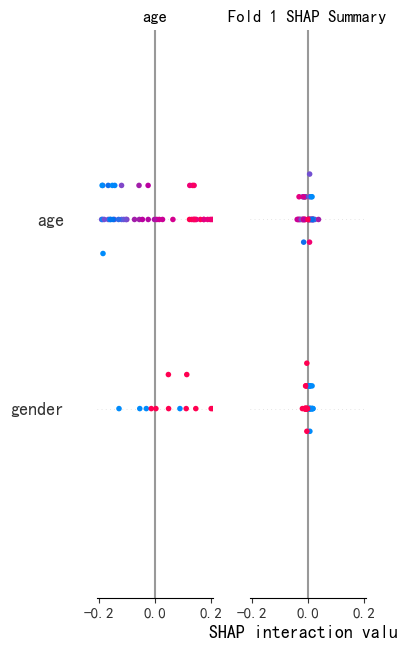


===== Random Forest Fold 2/5 =====
Fold 2: ACC=0.891, F1=0.869, AUC=0.892, Sensitivity=0.687, Specificity=1.000
[External RF] Fold 2: ACC=0.871, F1=0.713, AUC=0.780, Sensitivity=0.333, Specificity=1.000
[External RF] Confusion Matrix:
[[25  0]
 [ 4  2]]


C:\Users\25447\AppData\Local\Temp\ipykernel_35348\2035582225.py:259: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)


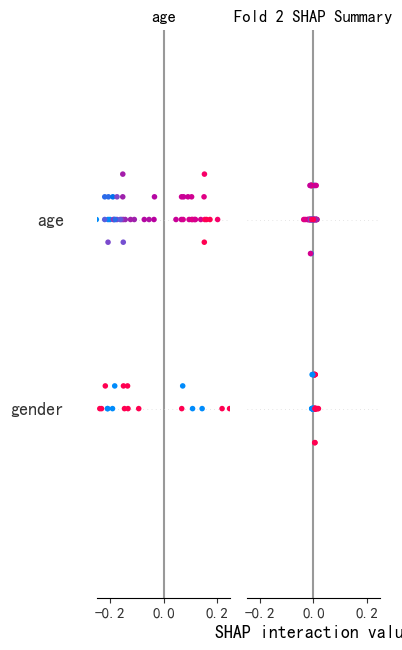


===== Random Forest Fold 3/5 =====
Fold 3: ACC=0.826, F1=0.775, AUC=0.917, Sensitivity=0.500, Specificity=1.000
[External RF] Fold 3: ACC=0.903, F1=0.805, AUC=0.740, Sensitivity=0.500, Specificity=1.000
[External RF] Confusion Matrix:
[[25  0]
 [ 3  3]]


C:\Users\25447\AppData\Local\Temp\ipykernel_35348\2035582225.py:259: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)


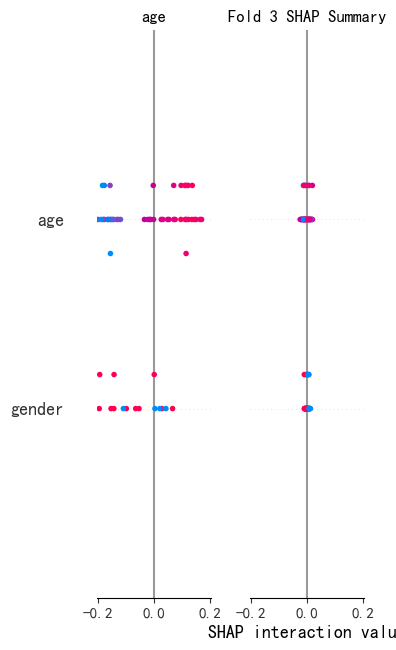


===== Random Forest Fold 4/5 =====
Fold 4: ACC=0.870, F1=0.839, AUC=0.966, Sensitivity=0.667, Specificity=0.968
[External RF] Fold 4: ACC=0.871, F1=0.713, AUC=0.780, Sensitivity=0.333, Specificity=1.000
[External RF] Confusion Matrix:
[[25  0]
 [ 4  2]]


C:\Users\25447\AppData\Local\Temp\ipykernel_35348\2035582225.py:259: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)


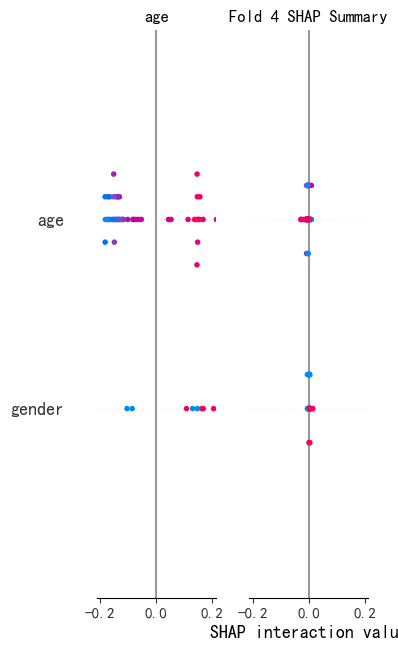


===== Random Forest Fold 5/5 =====
Fold 5: ACC=0.935, F1=0.924, AUC=0.972, Sensitivity=0.867, Specificity=0.968
[External RF] Fold 5: ACC=0.903, F1=0.805, AUC=0.810, Sensitivity=0.500, Specificity=1.000
[External RF] Confusion Matrix:
[[25  0]
 [ 3  3]]


C:\Users\25447\AppData\Local\Temp\ipykernel_35348\2035582225.py:259: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)


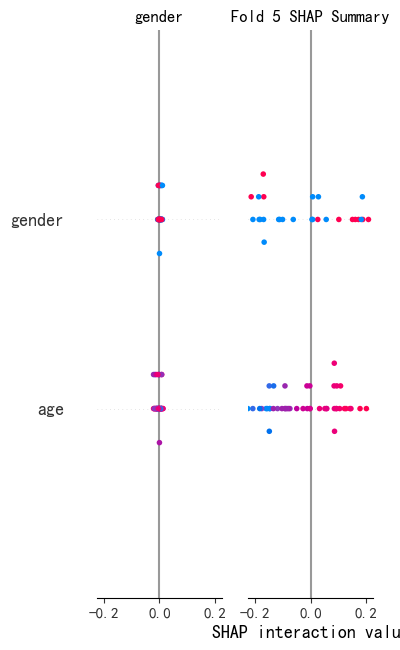


===== Random Forest K-Fold Final Results =====
Mean ACC=0.875 ± 0.037
Mean F1 =0.848 ± 0.049
Mean AUC=0.937 ± 0.030
Mean Sensitivity=0.694 ± 0.119
Mean Specificity=0.968 ± 0.035

===== Random Forest External Validation Results Across Fold Models =====
External Mean ACC=0.890 ± 0.016
External Mean F1 =0.768 ± 0.045
External Mean AUC=0.787 ± 0.030
External Mean Sensitivity=0.433 ± 0.082
External Mean Specificity=1.000 ± 0.000
Saved RF external per-sample predictions to rf_external_predictions_each_fold.xlsx


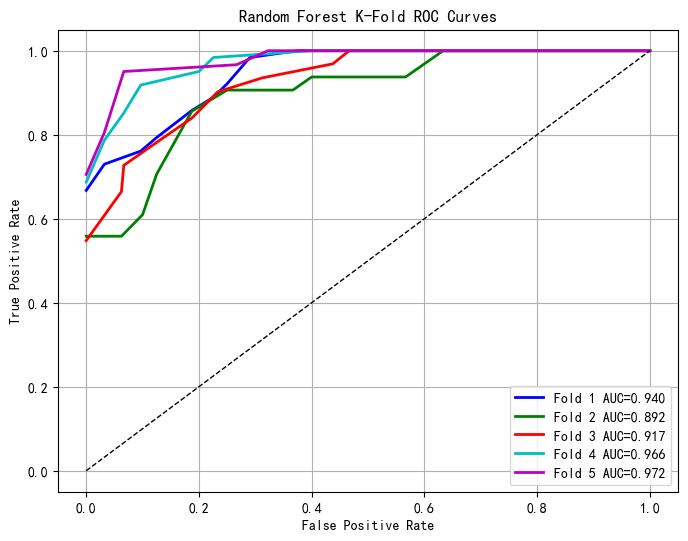

C:\Users\25447\AppData\Local\Temp\ipykernel_35348\2035582225.py:313: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="viridis")


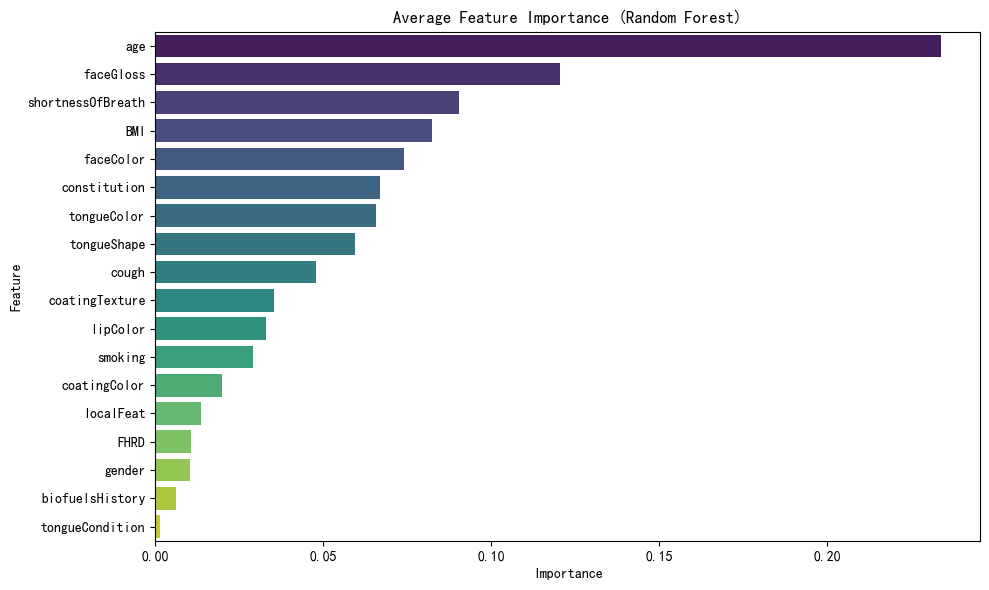

SHAP shape: (231, 18, 2)


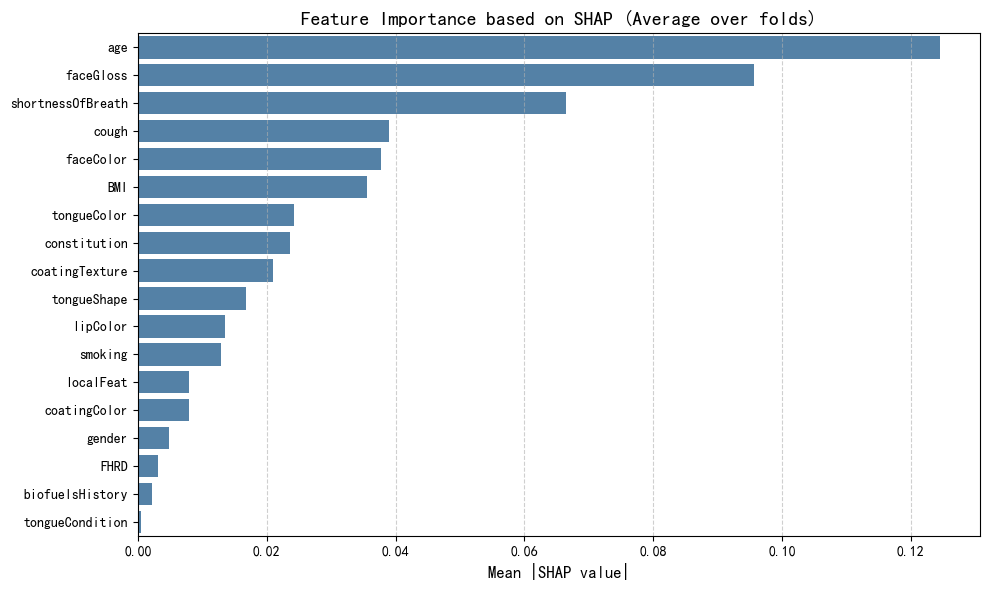

Detected SHAP format: (samples=231, features=18, classes=2)


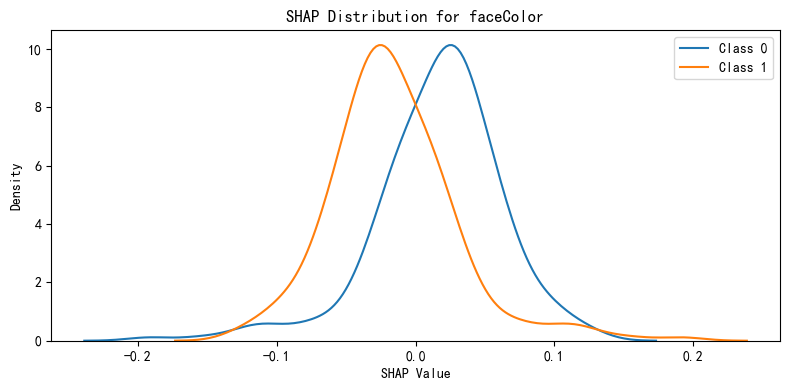

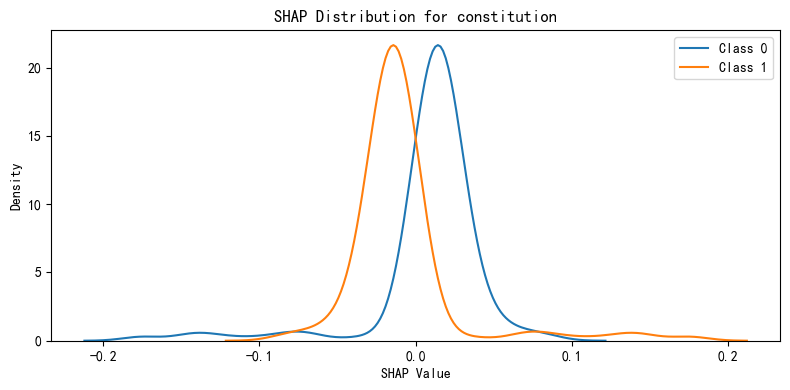

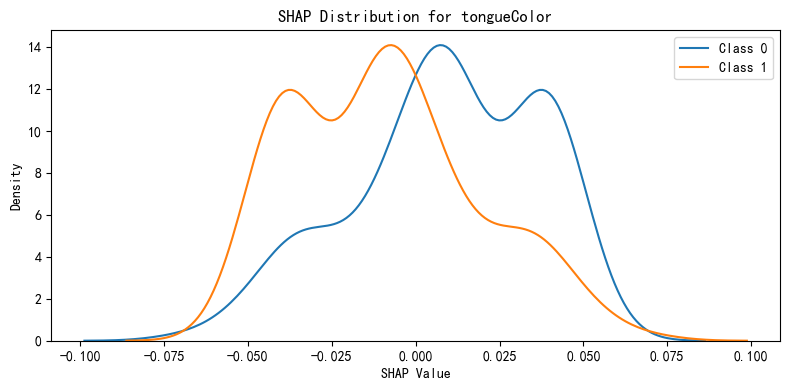

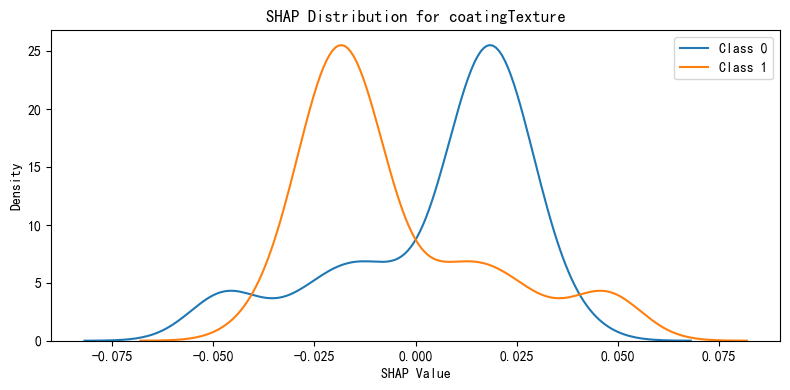

In [12]:
###########随机森林算法###############
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, f1_score, confusion_matrix
)
from itertools import cycle
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="shap")

feature_names = [
    "gender", "age",  "BMI", "smoking", "FHRD", "biofuelsHistory", "shortnessOfBreath", 'cough', #"COPD-SQ Score",#
    "constitution", "faceColor", "lipColor", "localFeat", "faceGloss", "tongueColor", "tongueShape", 'tongueCondition', "coatingTexture", "coatingColor"
]

def get_rf_positive_score(rf, X_test, positive_label=1):
    """
    安全获取随机森林阳性类别概率。
    返回：
    y_score: shape = (n_samples,) 的阳性概率
    y_prob : shape = (n_samples, n_classes) 的完整概率
    """
    y_prob = rf.predict_proba(X_test)

    if positive_label in rf.classes_:
        pos_idx = list(rf.classes_).index(positive_label)
        y_score = y_prob[:, pos_idx]
    else:
        y_score = np.full(X_test.shape[0], np.nan)

    # 强制保证 y_score 是一维
    y_score = np.asarray(y_score).reshape(-1)

    return y_score, y_prob


def safe_auc_no_nan(y_true, y_score, fold_name=""):
    """
    安全计算二分类 AUC。
    注意：y_score 必须是一维阳性概率。
    如果传进来的是二维 y_prob，会自动取第2列作为阳性概率。
    """

    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    # 如果误传了二维 y_prob，这里自动修正
    if y_score.ndim == 2:
        if y_score.shape[1] >= 2:
            print(f"[WARN] {fold_name} 传入的是二维 y_prob，已自动取 y_prob[:, 1] 作为阳性概率。")
            y_score = y_score[:, 1]
        else:
            print(f"[WARN] {fold_name} y_score 维度异常，本折AUC用0.5占位。")
            return 0.5

    y_score = y_score.reshape(-1)

    n0 = np.sum(y_true == 0)
    n1 = np.sum(y_true == 1)

    if len(np.unique(y_true)) < 2:
        print(
            f"[WARN] {fold_name} AUC无法真实计算：测试集只有一个类别。"
            f"n0={n0}, n1={n1}，本折AUC用0.5占位。"
        )
        return 0.5

    if np.isnan(y_score).any():
        print(
            f"[WARN] {fold_name} AUC无法真实计算：y_score含nan，"
            f"本折AUC用0.5占位。"
        )
        return 0.5

    try:
        auc = roc_auc_score(y_true, y_score)
    except Exception as e:
        print(f"[WARN] {fold_name} AUC计算失败：{e}，本折AUC用0.5占位。")
        auc = 0.5

    return auc



def extract_xy_from_dataset_for_biclass(dataset_obj):
    """从 MultimodalDataset 中提取 X/y，二分类标签：0=正常，1=通气功能异常/COPD。
    注意：不使用 sample.pop，避免改变 dataset 内部样本。"""
    X_list, y_list = [], []
    for idx in range(len(dataset_obj)):
        sample = dataset_obj[idx]
        label_raw = sample["isCopd"].item()
        bin_label = 0 if label_raw == 0 else 1
        feat_list = [v for k, v in sample.items() if k != "isCopd"]
        x = torch.cat(feat_list, dim=0).numpy()
        X_list.append(x)
        y_list.append(bin_label)
    return np.asarray(X_list), np.asarray(y_list)


def compute_binary_metrics_from_score(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_score = np.asarray(y_score).astype(float).reshape(-1)
    y_pred = (y_score >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    auc = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) == 2 else np.nan
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    sensitivity = TP / (TP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)
    return acc, f1, auc, sensitivity, specificity, cm

def evaluate_rf_with_shap(dataset, feature_names, k=5, n_estimators=300, random_state=42, external_dataset=None):
    """
    使用随机森林进行 K-Fold 交叉验证 + ROC曲线 + 特征重要性 + SHAP分析
    """

    # ===== 1. 提取数据 =====
    X, y = extract_xy_from_dataset_for_biclass(dataset)

    if external_dataset is not None:
        X_external, y_external = extract_xy_from_dataset_for_biclass(external_dataset)
        print("External X.shape", X_external.shape)
        print("External y.shape", y_external.shape)
        print("External label counts:", pd.Series(y_external).value_counts().to_dict())
    else:
        X_external, y_external = None, None

    n_features = X.shape[1]
    if len(feature_names) != n_features:
        print(f"[警告] feature_names长度({len(feature_names)})与X列数({n_features})不一致，自动截断或补全。")
        feature_names = feature_names[:n_features]

    # ===== 2. K-Fold 初始化 =====
    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
    all_auc, all_acc, all_f1 = [], [], []
    all_sens, all_spec = [], []

    # 外部验证集：每一折训练完成后，用该折随机森林直接验证外部集
    ext_all_acc, ext_all_f1, ext_all_auc, ext_all_sens, ext_all_spec = [], [], [], [], []
    # 保存每折外部验证的逐样本预测，用于后续bootstrap 95% CI
    ext_pred_rows = []

    all_importances = []
    fold_fpr, fold_tpr = [], []

    shap_summaries = []

    # ===== 3. 交叉验证 =====
    for fold, (train_idx, test_idx) in enumerate(kf.split(X, y)):
        print(f"\n===== Random Forest Fold {fold+1}/{k} =====")
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # 训练随机森林
        rf = RandomForestClassifier(
            n_estimators=n_estimators,
            random_state=random_state,
            class_weight="balanced",
            n_jobs=-1
        )
        rf.fit(X_train, y_train)

        # 预测
        y_pred = rf.predict(X_test)
        y_prob = rf.predict_proba(X_test)
        '''
        y_score, y_prob = get_rf_positive_score(
            rf,
            X_test,
            positive_label=1
        )
        '''

        # 计算指标
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="macro")
        auc = roc_auc_score(np.eye(len(np.unique(y)))[y_test], y_prob)
        '''
        auc = safe_auc_no_nan(
            y_true=y_test,
            y_score=y_score,   # 注意这里传 y_score，不是 y_prob
            fold_name=f"RF Fold {fold+1}"
        )
        '''
        all_acc.append(acc)
        all_f1.append(f1)
        all_auc.append(auc)

        # 灵敏度 & 特异性
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
        
        TN, FP, FN, TP = cm.ravel()
        
        sensitivity = TP / (TP + FN + 1e-8)  # 阳性识别率，召回率
        specificity = TN / (TN + FP + 1e-8)  # 阴性识别率

        all_sens.append(sensitivity)
        all_spec.append(specificity)

        print(f"Fold {fold+1}: ACC={acc:.3f}, F1={f1:.3f}, AUC={auc:.3f}, "
              f"Sensitivity={sensitivity:.3f}, Specificity={specificity:.3f}")

        # ---- External validation: 用当前fold训练后的随机森林直接验证外部集 ----
        if X_external is not None:
            ext_score, ext_prob = get_rf_positive_score(rf, X_external, positive_label=1)
            ext_acc, ext_f1, ext_auc, ext_sen, ext_spe, ext_cm = compute_binary_metrics_from_score(
                y_external, ext_score, threshold=0.5
            )
            ext_all_acc.append(ext_acc)
            ext_all_f1.append(ext_f1)
            ext_all_auc.append(ext_auc)
            ext_all_sens.append(ext_sen)
            ext_all_spec.append(ext_spe)
            ext_pred = (ext_score >= 0.5).astype(int)
            for sample_i, (yy, ss, pp) in enumerate(zip(y_external, ext_score, ext_pred)):
                ext_pred_rows.append({
                    "fold": fold + 1,
                    "sample_index": sample_i,
                    "y_true": int(yy),
                    "y_score": float(ss),
                    "y_pred": int(pp),
                    "is_wrong": bool(int(yy) != int(pp)),
                    "error_type": "Correct" if int(yy) == int(pp) else ("FN_false_negative" if int(yy) == 1 and int(pp) == 0 else "FP_false_positive")
                })
            print(f"[External RF] Fold {fold+1}: ACC={ext_acc:.3f}, F1={ext_f1:.3f}, AUC={ext_auc:.3f}, "
                  f"Sensitivity={ext_sen:.3f}, Specificity={ext_spe:.3f}")
            print("[External RF] Confusion Matrix:")
            print(ext_cm)

        # ROC曲线
        fpr, tpr = {}, {}
        for i in range(y_prob.shape[1]):
            fpr[i], tpr[i], _ = roc_curve(np.eye(len(np.unique(y)))[y_test][:, i], y_prob[:, i])
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(fpr))]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(len(fpr)):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= len(fpr)
        fold_fpr.append(all_fpr)
        fold_tpr.append(mean_tpr)

        # 特征重要性
        importances = rf.feature_importances_
        all_importances.append(importances)

        # SHAP 解释
        explainer = shap.TreeExplainer(rf)
        shap_values = explainer.shap_values(X_test)
        shap_summaries.append(shap_values)

        # 可视化单折SHAP（可选）
        shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
        plt.title(f"Fold {fold+1} SHAP Summary")
        plt.tight_layout()
        plt.show()

    # ===== 4. 汇总性能 =====
    print("\n===== Random Forest K-Fold Final Results =====")
    print(f"Mean ACC={np.mean(all_acc):.3f} ± {np.std(all_acc):.3f}")
    print(f"Mean F1 ={np.mean(all_f1):.3f} ± {np.std(all_f1):.3f}")
    print(f"Mean AUC={np.mean(all_auc):.3f} ± {np.std(all_auc):.3f}")
    print(f"Mean Sensitivity={np.mean(all_sens):.3f} ± {np.std(all_sens):.3f}")
    print(f"Mean Specificity={np.mean(all_spec):.3f} ± {np.std(all_spec):.3f}")

    if external_dataset is not None and len(ext_all_acc) > 0:
        print("\n===== Random Forest External Validation Results Across Fold Models =====")
        print(f"External Mean ACC={np.mean(ext_all_acc):.3f} ± {np.std(ext_all_acc):.3f}")
        print(f"External Mean F1 ={np.mean(ext_all_f1):.3f} ± {np.std(ext_all_f1):.3f}")
        print(f"External Mean AUC={np.nanmean(ext_all_auc):.3f} ± {np.nanstd(ext_all_auc):.3f}")
        print(f"External Mean Sensitivity={np.mean(ext_all_sens):.3f} ± {np.std(ext_all_sens):.3f}")
        print(f"External Mean Specificity={np.mean(ext_all_spec):.3f} ± {np.std(ext_all_spec):.3f}")
        pd.DataFrame({
            "fold": np.arange(1, len(ext_all_acc) + 1),
            "ACC": ext_all_acc,
            "F1": ext_all_f1,
            "AUC": ext_all_auc,
            "Sensitivity": ext_all_sens,
            "Specificity": ext_all_spec,
        }).to_excel("rf_external_validation_each_fold.xlsx", index=False)
        if len(ext_pred_rows) > 0:
            pd.DataFrame(ext_pred_rows).to_excel("rf_external_predictions_each_fold.xlsx", index=False)
            print("Saved RF external per-sample predictions to rf_external_predictions_each_fold.xlsx")

    # ===== 5. 画ROC曲线 =====
    plt.figure(figsize=(8, 6))
    colors = cycle(['b', 'g', 'r', 'c', 'm', 'y', 'k'])
    for i, (fpr_i, tpr_i) in enumerate(zip(fold_fpr, fold_tpr)):
        plt.plot(fpr_i, tpr_i, color=next(colors), lw=2,
                 label=f'Fold {i+1} AUC={all_auc[i]:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Random Forest K-Fold ROC Curves")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

    # ===== 6. 全折特征重要性 =====
    mean_importance = np.mean(all_importances, axis=0)
    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": mean_importance
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="viridis")
    plt.title("Average Feature Importance (Random Forest)")
    plt.tight_layout()
    plt.show()

    # ===== 7. 重要特征SHAP可视化 =====
   
    shap_values_all = np.concatenate(shap_summaries, axis=0)  # 合并所有折
    shap_array = np.array(shap_values_all)
    print("SHAP shape:", shap_array.shape)

    mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 2))  # (feature, )

    # === 构建 DataFrame 并排序 ===
    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Mean |SHAP|": mean_abs_shap
    }).sort_values(by="Mean |SHAP|", ascending=False)
    
    # === 绘制特征重要性条形图 ===
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x="Mean |SHAP|", 
        y="Feature", 
        data=feature_importance_df, 
        color="steelblue"
    )
    plt.title("Feature Importance based on SHAP (Average over folds)", fontsize=14, weight='bold')
    plt.xlabel("Mean |SHAP value|", fontsize=12)
    plt.ylabel("")
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # === 修改开始 ===
    n_samples, n_features, n_classes = shap_array.shape
    print(f"Detected SHAP format: (samples={n_samples}, features={n_features}, classes={n_classes})")
    
    # 遍历特征进行绘图
    for feat in ["faceColor", "constitution", "tongueColor", "coatingTexture"]:
        if feat not in feature_names:
            continue
        feat_idx = feature_names.index(feat)
    
        plt.figure(figsize=(8, 4))
        for class_idx in range(n_classes):
            # 取出该特征在所有样本中、该类别下的 SHAP 值
            shap_vals = shap_array[:, feat_idx, class_idx]
            shap_df = pd.DataFrame({
                "SHAP": shap_vals,
                "Label": [f"Class {class_idx}"] * len(shap_vals)
            })
            sns.kdeplot(data=shap_df, x="SHAP", label=f"Class {class_idx}")
    
        plt.title(f"SHAP Distribution for {feat}")
        plt.xlabel("SHAP Value")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return feature_importance_df, shap_summaries, all_acc, all_f1, all_auc, all_sens, all_spec


# ===== 执行 =====
rf_feature_importance, rf_shap_values, all_acc, all_f1, all_auc, all_sens, all_spec= evaluate_rf_with_shap(
    dataset, feature_names=feature_names, k=5, n_estimators=300, external_dataset=external_dataset
)


In [13]:

# ============================================================
# 外部验证 95% CI 计算函数：基于每折模型对外部集的逐样本预测
# ============================================================
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix


def compute_external_metrics_ci_once(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_score = np.asarray(y_score).astype(float).reshape(-1)
    valid_mask = (y_true >= 0) & np.isfinite(y_score)
    y_true = y_true[valid_mask]
    y_score = y_score[valid_mask]
    y_pred = (y_score >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    auc = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) == 2 else np.nan
    TN, FP, FN, TP = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = TP / (TP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)
    ppv = TP / (TP + FP + 1e-8)
    npv = TN / (TN + FN + 1e-8)
    return {
        "ACC": acc,
        "F1": f1,
        "AUC": auc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "PPV": ppv,
        "NPV": npv,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "TP": TP,
    }


def bootstrap_external_95ci(y_true, y_score, threshold=0.5, n_bootstrap=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_score = np.asarray(y_score).astype(float).reshape(-1)
    valid_mask = (y_true >= 0) & np.isfinite(y_score)
    y_true = y_true[valid_mask]
    y_score = y_score[valid_mask]

    point_metrics = compute_external_metrics_ci_once(y_true, y_score, threshold=threshold)
    n = len(y_true)
    boot_rows = []
    for _ in range(n_bootstrap):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        y_b = y_true[idx]
        s_b = y_score[idx]
        # 若某次重采样只有单一类别，则AUC不可定义，跳过该次
        if len(np.unique(y_b)) < 2:
            continue
        boot_rows.append(compute_external_metrics_ci_once(y_b, s_b, threshold=threshold))

    boot_df = pd.DataFrame(boot_rows)
    ci_rows = []
    for metric in ["ACC", "F1", "AUC", "Sensitivity", "Specificity", "PPV", "NPV"]:
        vals = boot_df[metric].dropna().values
        ci_rows.append({
            "Metric": metric,
            "Point_Estimate": point_metrics[metric],
            "CI_lower": np.percentile(vals, 2.5),
            "CI_upper": np.percentile(vals, 97.5),
            "Bootstrap_Mean": np.mean(vals),
            "Bootstrap_Std": np.std(vals, ddof=1),
            "N_bootstrap_valid": len(vals),
        })
    return pd.DataFrame(ci_rows), boot_df, point_metrics


def external_ci_from_fold_prediction_file(prediction_file, output_file, threshold=0.5, n_bootstrap=1000, seed=42):
    """
    prediction_file: 由训练函数保存的逐样本外部预测文件，例如 dnn_external_predictions_each_fold.xlsx。
    做法：先对同一个 sample_index 的多个fold预测概率取平均，作为该样本最终外部预测分数，
    再在外部样本层面做bootstrap 95% CI。
    """
    pred_all = pd.read_excel(prediction_file)
    required_cols = {"sample_index", "y_true", "y_score"}
    missing = required_cols - set(pred_all.columns)
    if missing:
        raise ValueError(f"{prediction_file} 缺少必要列: {missing}")

    pred_ens = (
        pred_all
        .groupby("sample_index", as_index=False)
        .agg(
            y_true=("y_true", "first"),
            y_score=("y_score", "mean"),
            y_score_std=("y_score", "std"),
            n_fold=("y_score", "count")
        )
    )
    pred_ens["y_pred"] = (pred_ens["y_score"] >= threshold).astype(int)
    pred_ens["is_wrong"] = pred_ens["y_true"] != pred_ens["y_pred"]
    pred_ens["error_type"] = pred_ens.apply(
        lambda row: "Correct" if row["y_true"] == row["y_pred"]
        else ("FN_false_negative" if row["y_true"] == 1 and row["y_pred"] == 0 else "FP_false_positive"),
        axis=1
    )

    ci_df, boot_df, point_metrics = bootstrap_external_95ci(
        y_true=pred_ens["y_true"].values,
        y_score=pred_ens["y_score"].values,
        threshold=threshold,
        n_bootstrap=n_bootstrap,
        seed=seed,
    )

    summary_df = pd.DataFrame([{"threshold": threshold, **point_metrics}])
    wrong_df = pred_ens[pred_ens["is_wrong"]].copy()

    print("\n===== External Validation Metrics with 95% CI =====")
    print(f"Prediction file: {prediction_file}")
    print(f"Decision threshold = {threshold:.2f}")
    for _, row in ci_df.iterrows():
        print(f"{row['Metric']}: {row['Point_Estimate']:.3f} [95% CI: {row['CI_lower']:.3f}-{row['CI_upper']:.3f}]")
    print("\nConfusion matrix [[TN, FP], [FN, TP]]:")
    print(np.array([[point_metrics["TN"], point_metrics["FP"]], [point_metrics["FN"], point_metrics["TP"]]]))
    print("\nWrong prediction counts:")
    print(wrong_df["error_type"].value_counts())

    with pd.ExcelWriter(output_file) as writer:
        summary_df.to_excel(writer, sheet_name="external_summary", index=False)
        ci_df.to_excel(writer, sheet_name="external_95CI", index=False)
        pred_ens.to_excel(writer, sheet_name="external_predictions", index=False)
        wrong_df.to_excel(writer, sheet_name="wrong_predictions", index=False)
        boot_df.to_excel(writer, sheet_name="bootstrap_samples", index=False)

    print(f"Saved external CI results to {output_file}")
    return ci_df, pred_ens, wrong_df, boot_df

# ============================================================
# 随机森林外部验证：基于5折模型外部预测的集成概率，计算bootstrap 95% CI
# 运行前请先运行上面的随机森林函数，并确保生成 rf_external_predictions_each_fold.xlsx
# ============================================================
RF_EXTERNAL_PRED_FILE = "rf_external_predictions_each_fold.xlsx"
RF_EXTERNAL_CI_OUTPUT = "rf_external_validation_95CI.xlsx"
RF_DECISION_THRESHOLD_FOR_CI = 0.50  # 可改为0.10/0.20/0.30

ci_rf_df, rf_pred_ens_df, rf_wrong_df, rf_boot_df = external_ci_from_fold_prediction_file(
    prediction_file=RF_EXTERNAL_PRED_FILE,
    output_file=RF_EXTERNAL_CI_OUTPUT,
    threshold=RF_DECISION_THRESHOLD_FOR_CI,
    n_bootstrap=1000,
    seed=42,
)



===== External Validation Metrics with 95% CI =====
Prediction file: rf_external_predictions_each_fold.xlsx
Decision threshold = 0.50
ACC: 0.871 [95% CI: 0.742-0.968]
F1: 0.713 [95% CI: 0.446-0.919]
AUC: 0.787 [95% CI: 0.481-1.000]
Sensitivity: 0.333 [95% CI: 0.000-0.750]
Specificity: 1.000 [95% CI: 1.000-1.000]
PPV: 1.000 [95% CI: 0.000-1.000]
NPV: 0.862 [95% CI: 0.724-0.966]

Confusion matrix [[TN, FP], [FN, TP]]:
[[25  0]
 [ 4  2]]

Wrong prediction counts:
error_type
FN_false_negative    4
Name: count, dtype: int64
Saved external CI results to rf_external_validation_95CI.xlsx
